# Krater diffusion aus einem DEM-Profil (Shapefile-Line)

Angepasst von: Hobley, D. E. J., et al. (2017). "Landlab: a python package for the numerical modeling of earth surface dynamics—foundation and user interface", Earth Surface Dynamics, 5(1), 21-38. UND Barnhart, K. R., et al. (2020), "Representing Earth surface processes in Python with Landlab v2.0: A software architecture for components", Geoscientific Model Development, 13(3), 1263-1283.

Dieses Notebook:
1. lädt ein **DEM (GeoTIFF)**
2. lädt zwei **Shapefile** mit **genau einer Linie** (Profil-Transect; Ursprüngicher Durchmesser (selbes Profil))
3. sampelt das DEM entlang der Linie
4. berechnet eine **sehr einfache Diffusionsabschätzung** über die **10–90%-Übergangsbreite** bzw. **90%-Radius** 

**Wichtig:** DEM und Shapefile müssen im gleichen metrischen CRS sein (z. B. UTM/GK).

Code aus der Bachelorarbeit: Kalibrierung von Bruchstufendiffusionsmodellen mit Bombenkratern im Niederrheingraben; von Gabriel Farman; abgegeben am 15.07.2026 am Münchner Geozentrum; Betreuer: PD Dr. Simon Kübler

In [1]:
# --- Install (falls nötig) ---
# !pip install rasterio geopandas shapely numpy pandas scipy matplotlib

import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import math
import pyproj
from shapely.geometry import LineString
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.transforms import IdentityTransform
from matplotlib.legend_handler import HandlerPatch
from matplotlib.ticker import FormatStrFormatter  # oder FuncFormatter
import matplotlib.ticker as mticker
from scipy.special import erf
from scipy.special import lambertw
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# Generelle Einstellungen zu den Plots
plt.rcParams.update({
  'font.size': 10,
  'lines.linewidth': 1.2,
  'axes.linewidth': 0.8,
})

print('Imports OK')

Imports OK


## 1) Pfade & Parameter

In [2]:
# --- EDIT THESE ---
DEM_PATH = 'dgm1_32_352_5627_1_nw_2022.tif'                         # GeoTIFF DEM 
PROFILE_SHP = '1b.shp'             # Shapefile with 1 LineString (crater profile)
ORIGINAL_DIAMETER_SHP = '1bx.shp'  # Shapefile with 1 Linestring (devide to devide (1944) along the same profile

# Sampling step along profile (meters). Choose <= DEM resolution.
DS = 1 #0.5  # 1 #0.25

# Age since formation (years). Example: WW2 crater ~1944 -> LiDAR year (e.g., 2022) => 2022-1944 = 78
T_YEARS = 2022-1944 # 80.0

# How far from each end of the Profile to compute 'outside' reference levels (meters)
# (Used to estimate z_top)
REF_MARGIN_M = 3  # 10  #3.0

# --- Optional profile smoothing (recommended for small craters / noisy profiles) ---
SMOOTH_PROFILE = True
# Savitzky–Golay settings (window_length must be odd; units are samples, i.e. ~meters if DS=1m)
SG_WINDOW = 4       # try 4 to 15
SG_POLYORDER = 2

print('Parameters set')

Parameters set


## 2) DEM & Profil-Linie laden

Erwartung: Das Shapefile enthält **eine** Linie. Falls mehrere, wird die erste genommen.

Außerdem werden das DGM und die Shapefiles in das selbe CRS projiziert und die Profillänge, der Ursprüngliche Kraterradius und der Azimut der Profillinie berechnet

In [3]:
with rasterio.open(DEM_PATH) as src:
    dem_crs = src.crs
    dem_res = src.res
    dem_nodata = src.nodata
    print('DEM CRS:', dem_crs)
    print('DEM res:', dem_res)
    print('DEM nodata:', dem_nodata)

gdf = gpd.read_file(PROFILE_SHP)
print('Shapefile CRS:', gdf.crs)
print('Number of features:', len(gdf))

#same for original crater profile (second Shapefile: ORIGINAL_DIAMETER_SHP)
gdf_or = gpd.read_file(ORIGINAL_DIAMETER_SHP) 

if len(gdf) < 1 or len(gdf_or) < 1:
    raise ValueError('Shapefile contains no features.')

# Reproject line to DEM CRS if needed
if gdf.crs != dem_crs:
    print('Reprojecting profile line to DEM CRS...')
    gdf = gdf.to_crs(dem_crs)
    
#same for original crater profile
if gdf_or.crs != dem_crs:
    print('Reprojecting original profile  to DEM CRS...')
    gdf_or = gdf_or.to_crs(dem_crs)

geom = gdf.geometry.iloc[0]
geom_or = gdf_or.geometry.iloc[0]
if geom is None or geom_or is None:
    raise ValueError('First geometry is None.')


# If multiline, merge to a single LineString
if geom.geom_type == 'MultiLineString':
    coords = []
    for ls in geom.geoms:
        coords.extend(list(ls.coords))
    geom = LineString(coords)
    
#same for original crater profile
if geom_or.geom_type == 'MultiLineString':
    coords = []
    for ls in geom_or.geoms:
        coords.extend(list(ls.coords))
    geom = LineString(coords)

if geom.geom_type != 'LineString':
    raise ValueError(f'Expected LineString, got {geom.geom_type}')

#same for original crater profile
if geom_or.geom_type != 'LineString':
    raise ValueError(f'Expected LineString, got {geom_or.geom_type}')

# Azimut of profile line is calculated
def azimut(line):
    x1,y1 = line.coords[0]
    x2,y2 = line.coords[-1]
    dx = x2-x1
    dy = y2-y1
    angle = math.degrees(math.atan2(dx,dy))

    if angle < 0:
        angle += 360
    return float(angle)
gdf["azimut"] = gdf.geometry.apply(azimut)
Azimut_right = azimut(gdf.geometry.iloc[0])
  
if Azimut_right < 180:
    Azimut_left = Azimut_right + 180
else: Azimut_left = Azimut_right - 180

or_diameter = geom_or.length

print('Azimut left:', Azimut_left)
print('Azimut right:', Azimut_right)
print('Profile length (m):', geom.length)
print('Original crater diameter (m):', or_diameter)

DEM CRS: EPSG:25832
DEM res: (1.0, 1.0)
DEM nodata: -9999.0
Shapefile CRS: EPSG:25832
Number of features: 1
Azimut left: 1.1885386092272654
Azimut right: 181.18853860922727
Profile length (m): 16.491011162271473
Original crater diameter (m): 8.14369914284159


## 3) DEM entlang der Linie sampeln

In [4]:
def sample_dem_along_linestring(src, line: LineString, ds=0.25):
    """Sample a DEM along a LineString every ds meters. Returns distance s (m), x,y, and z."""
    L = line.length
    n = int(np.floor(L / ds)) + 1
    dists = np.linspace(0.0, L, n)
    pts = [line.interpolate(float(d)) for d in dists]
    xs = np.array([p.x for p in pts])
    ys = np.array([p.y for p in pts])

    z = np.array([v[0] for v in src.sample(list(zip(xs, ys)))], dtype=float)
    if src.nodata is not None:
        z[z == src.nodata] = np.nan
    return dists, xs, ys, z

with rasterio.open(DEM_PATH) as src:
    s, xs, ys, z = sample_dem_along_linestring(src, geom, ds=DS)

print('Samples:', len(s), 'NaNs:', np.isnan(z).sum())
df_prof = pd.DataFrame({'s_m': s, 'x': xs, 'y': ys, 'z_m': z})
df_prof.head()

Samples: 17 NaNs: 0


,s_m,x,y,z_m
0,0.000000,352121.178516,5.627429e+06,157.720001
1,1.030688,352121.157137,5.627428e+06,157.729996
2,2.061376,352121.135758,5.627426e+06,157.750000
3,3.092065,352121.114379,5.627425e+06,157.800003
4,4.122753,352121.093000,5.627424e+06,157.839996


## 3b) Optional: Profil glätten (empfohlen bei 1 m DEM und kleinen Kratern)

Wenn das Profil stark „pixelig“/rauschig ist (z. B. 1 m DEM und Krater ~10 m Durchmesser), kann eine moderate 1D-Glättung helfen, die Rim-Form robust zu messen. Hier wird ein **Savitzky–Golay Filter** genutzt, der die Form besser erhält als ein einfacher Moving Average.

Wir rechnen die Diffusivität danach standardmäßig auf dem geglätteten Profil (falls `SMOOTH_PROFILE=True`).


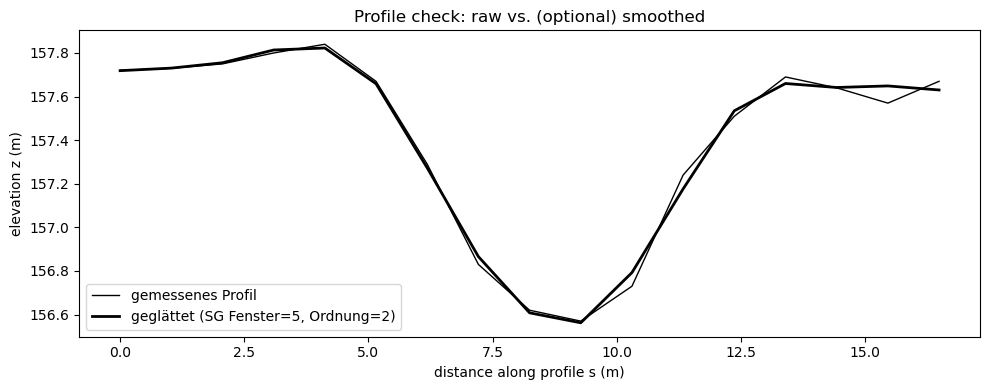

Samples: 17 NaNs z_use: 0
Samples: 17 NaNs z_filled: 0


In [5]:
# Build a smoothed profile (optional)
z_use = z.copy()

if SMOOTH_PROFILE:
    wl = int(SG_WINDOW)
    if wl % 2 == 0:
        wl += 1
    valid = np.isfinite(z)
    if valid.sum() < (wl + 2):
        raise ValueError('Too few valid samples for the chosen smoothing window. Reduce SG_WINDOW or improve data.')
    
    # fill NaNs for filtering (temporary) using median
    z_fill = z.copy()
    z_fill[~valid] = np.nanmedian(z[valid])
    z_smooth = savgol_filter(z_fill, window_length=wl, polyorder=int(SG_POLYORDER), mode='interp')
    z_smooth[~valid] = np.nan
    
    # fill all Nans with mean of nearest valid neighbors or nearest valid neighbor (for NaNs on the edge) 
    n = len(z_smooth)
    indices = np.arange(n)
    valid_smooth = np.isfinite(z_smooth)
    z_filled = np.copy(z_smooth)
    if np.sum(valid_smooth) >= 2:
        if np.any(~valid_smooth):
            z_filled[~valid_smooth] = np.interp(indices[~valid_smooth], indices[~valid_smooth], z_smooth[~valid_smooth])
            first_valid = np.argmax(valid)
            z_filled[:first_valid] = z_smooth[first_valid]
            last_valid = len(z_smooth) - 1 - np.argmax(valid[::-1])
            z_filled[last_valid+1:] = z_smooth[last_valid]
        else: z_filled = z_smooth
    
    z_use = z_filled #z_smooth
else:
    z_smooth = None

# Quick visual check
plt.figure(figsize=(10,4))
plt.plot(s, z, linewidth=1, linestyle='-',color='black', label='gemessenes Profil')
if z_smooth is not None:
    plt.plot(s, z_use, linewidth=2, linestyle='-', color='black', label=f'geglättet (SG Fenster={wl}, Ordnung={SG_POLYORDER})')
plt.xlabel('distance along profile s (m)')
plt.ylabel('elevation z (m)')
plt.title('Profile check: raw vs. (optional) smoothed')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
print('Samples:', len(s), 'NaNs z_use:', np.isnan(z_use).sum())
print('Samples:', len(s), 'NaNs z_filled:', np.isnan(z_filled).sum())


### Hinweis
Ab hier wird standardmäßig mit `z_for_analysis` weitergerechnet (geglättetes Profil, falls aktiviert). Das Rohprofil `z` bleibt weiterhin verfügbar.


In [6]:
# Ensure all subsequent analysis uses the chosen profile
if SMOOTH_PROFILE == True:
    z_for_analysis = z_use
else: z_for_analysis = z

# (Optional) also store in the dataframe for export/inspection
try:
    df_prof['z_used_m'] = z_for_analysis
except Exception:
    pass


## 4) Bestimmung einfacher Parameter auf dem Profil und Normierung der Profile
Die Profile werden erst am Kratertiefpunkt in zwei profile geteilt und anschließend so normiert, dass sie aufsteigende werte haben und die Horizontale Strecke bei 0 am Kratertiefpunkt beginnt (z.b. praktisch für Volumenberechnung)

In [7]:
# Splitting Profile into a left and right Profile by interpolating z_bot

# Crater bottom
z_bot = min(z_for_analysis)
i_bot = np.argmin(z_for_analysis)
s_bot = s[i_bot]


s_bot_EPSG_25832 = gdf.interpolate(s_bot)   # s_bot in meters PROFILE_SHP
s_bot_x, s_bot_y = s_bot_EPSG_25832.x, s_bot_EPSG_25832.y
proj_from = pyproj.CRS(dem_crs) #pyproj.CRS("EPSG:25832")
proj_to   = pyproj.CRS("EPSG:4326")
transformer = pyproj.Transformer.from_crs(proj_from, proj_to, always_xy=True)
s_bot_lon, s_bot_lat = transformer.transform(s_bot_x, s_bot_y)
lat = s_bot_lat[0]
lon = s_bot_lon[0]
print('s_bot Coordinates WGS84:',f"{lat:.8f}, {lon:.8f}")

# Creating split profiles for smoothed values
s_array = np.array(list(s))
mask_left = s_array <= s_bot
s_left = s[mask_left]#s <= s_bot
z_left = z[mask_left]

mask_right = s_array >= s_bot
s_right = s[mask_right]
z_right = z[mask_right]

z_left_for_analysis = z_for_analysis[mask_left]
z_right_for_analysis = z_for_analysis[mask_right]

# Creating normalized profiles (s[0] = 0)
s_right2 = s_right - s_right[0]
s_left2 = (s_left[-1] - s_left)[::-1]
z_left2 = z_left[::-1]
z_left_for_analysis2 = z_left_for_analysis[::-1]
z_right2 = z_right
z_right_for_analysis2 = z_right_for_analysis

# Measuring the drainage devide (highest point on the profile)
z_devide_left = np.nanmax(z_left_for_analysis)
z_devide_right = np.nanmax(z_right_for_analysis)

# s_devide is derived from the smoothed values. 
i_left = np.argmax(z_left_for_analysis)    
s_devide_left = s_left[i_left]
i_right = np.argmax(z_right_for_analysis)
s_devide_right = s_right[i_right]

# drainage devide on the normalized profile
s_devide_right2 = s_devide_right - s_right[0]
s_devide_left2 = s_left[-1] - s_devide_left

# elevation difference
deltaz_left = z_devide_left - z_bot
deltaz_right = z_devide_right - z_bot

print('z_bot:', z_bot)
print('s_bot:', s_bot)
print('REF_MARGIN_M:', REF_MARGIN_M)
print('z_devide_left:', z_devide_left)
print('s_devide_left:', s_devide_left)
print('z_devide_right:', z_devide_right)
print('s_devide_right:', s_devide_right)
print('Elevation difference left:', deltaz_left)
print('Elevation difference right:', deltaz_right)


s_bot Coordinates WGS84: 50.77965087, 6.90237455
z_bot: 156.56228550502217
s_bot: 9.276193778777703
REF_MARGIN_M: 3
z_devide_left: 157.82285635811925
s_devide_left: 4.122752790567868
z_devide_right: 157.659997994559
s_devide_right: 13.398946569345572
Elevation difference left: 1.2605708530970787
Elevation difference right: 1.097712489536832


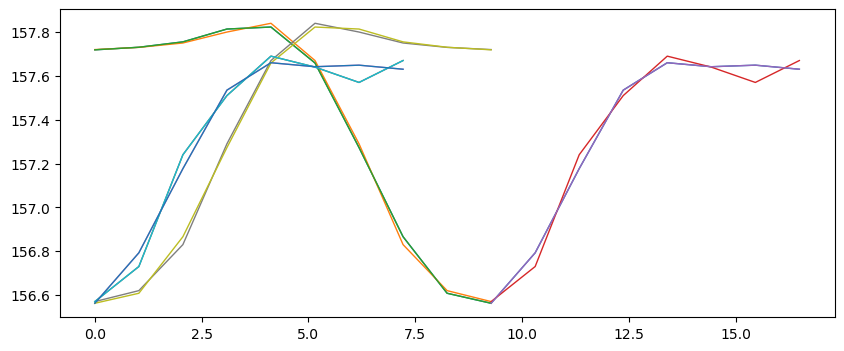

In [8]:
# Quick visualization of the normalized profiles
plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, label='z_analysis')
plt.plot(s_left, z_left, linewidth=1, label='z_left')
plt.plot(s_left, z_left_for_analysis, linewidth=1, label='z_left_for_analysis')
plt.plot(s_right, z_right, linewidth=1, label='z_right')
plt.plot(s_right, z_right_for_analysis, linewidth=1, label='z_right_for_analysis')
plt.plot(s_right2, z_right, linewidth=1, label='z_right2')
plt.plot(s_right2, z_right_for_analysis, linewidth=1, label='z_right_for_analysis2')
plt.plot(s_left2, z_left2, linewidth=1, label='z_left2')
plt.plot(s_left2, z_left_for_analysis2, linewidth=1, label='z_left_for_analysis2')
plt.plot(s_right2, z_right2, linewidth=1, label='z_right2')
plt.plot(s_right2, z_right_for_analysis2, linewidth=1, label='z_right_for_analysis2')

## 5) Einfache Diffusionsabschätzung über 10–90%-Breite (aus senkrechter Stufe)

Annahme 1: Das Profil ist aus der Diffusion einer unendlichen senkrechten Stufe ohne Konvergenz und Begrenzung des Materialtransports entstanden

Annahme 2: Der Kraterrand verhält sich lokal wie eine geglättete Stufe. 

\[
\Delta x_{10–90} \approx 3.6\, \sqrt{D\,t}
\]

\[
D \approx \frac{(\Delta x/3.6)^2}{t}
\]

**Wichtig:** Das liefert eine *erste Größenordnung* für eine *effektive* Diffusivität. Für Krater mit einem (nicht senkrechten) Ursprungsprofil muss es weiter angepasst werden.

In [9]:
# Calculate D from left profile
def estimate_D_from_left_profile(s_left, z_left_for_analysis, t_years, ref_margin_m=10.0):
    """Estimate diffusivity D (m^2/yr) from 10-90% transition width.
    Uses reference levels from the first/last ref_margin_m of the profile.
    Returns dict with D, dx, and picked points.
    """
    m = np.isfinite(z_left_for_analysis)
    if m.sum() < 10:
        raise ValueError('Too few valid elevation samples.')

    # reference windows
    L = float(s[-1])
    left = (s <= ref_margin_m) & m
    #if left.sum() < 3:
        #raise ValueError('Reference windows too small; increase profile length or reduce REF_MARGIN_M.')

    z_top_left = np.nanmedian(z_left_for_analysis[left]) 
    H_left = z_top_left - z_bot #H = z_top - z_bot
    if H_left <= 0: 
        raise ValueError('Non-positive relief across profile. Check that the line crosses a scarp/rim.')
    
    z10_left = z_bot + 0.1 * H_left #z10 = z_bot + 0.1 * H
    z90_left = z_bot + 0.9 * H_left #z90 = z_bot + 0.9 * H
    
    # We need monotonic-ish z(s) across the rim. We'll use interpolation on the sorted-by-z curve.
    # Practical: find closest indices where z crosses z10/z90.
    # Use linear interpolation between bracketing points.
    def crossing_s(target):
        # find segments where z - target changes sign
        zz = z_left_for_analysis.copy()
        ss = s_left.copy()
        mm = np.isfinite(zz)
        zz = zz[mm]
        ss = ss[mm]
        d = zz - target
        sign = np.sign(d)
        # indices where sign changes
        idx = np.where(sign[:-1] * sign[1:] <= 0)[0]
        if len(idx) == 0:
            # fallback: nearest point
            j = int(np.nanargmin(np.abs(d)))
            return float(ss[j])
        # choose crossing closest to mid-profile (often the rim is central)
        nonlocal mid_left
        mid_left = 0.5 * (ss[0] + s_bot) #mid_left = 0.5 * (ss[0] + ss[-1])
        candidates = []
        for i in idx:
            s0, s1 = ss[i], ss[i+1]
            z0, z1 = zz[i], zz[i+1]
            if z1 == z0:
                sc = 0.5 * (s0 + s1)
            else:
                sc = s0 + (target - z0) * (s1 - s0) / (z1 - z0)
            candidates.append(sc)
        candidates = np.array(candidates)
        return float(candidates[np.argmin(np.abs(candidates - mid_left))])

    s10_left = crossing_s(z10_left)#s10 = crossing_s(z10)
    s90_left = crossing_s(z90_left)#s90 = crossing_s(z90)
    dx_left = abs(s90_left - s10_left) #dx = abs(s90 - s10)
    mid_left = mid_left

    D_left = (dx_left / 3.624)**2 / float(t_years) #D = (dx / 3.6)**2 / float(t_years)
    
    return {
        'z_top_left': float(z_top_left),
        'H_left': float(H_left), #'H': float(H), 'z_top': float(z_top),
        'z10_left': float(z10_left), 'z90_left': float(z90_left),#'z10': float(z10), 'z90': float(z90),
        's10_left': float(s10_left), 's90_left': float(s90_left),#'s10': float(s10), 's90': float(s90),
        'dx_10_90_left_m': float(dx_left),#'dx_10_90_m': float(dx),
        'D_left_m2_per_yr': float(D_left), #'D_m2_per_yr': float(D)
        'mid_left': float(mid_left)
    }

# Calculate D from left profile
def estimate_D_from_right_profile(s_right, z_right_for_analysis, t_years, ref_margin_m=10.0):
    
    m = np.isfinite(z_right_for_analysis)
    if m.sum() < 10:
        raise ValueError('Too few valid elevation samples.')

    # reference windows
    L = float(s[-1])
    right = (s >= (L +1 - ref_margin_m)) & m
    #if right.sum() < 3:
        #raise ValueError('Reference windows too small; increase profile length or reduce REF_MARGIN_M.')

    z_top_right = np.nanmedian(z_right_for_analysis[right]) 
    H_right = z_top_right - z_bot
    if H_right <=0: #if H <= 0:
        raise ValueError('Non-positive relief across profile. Check that the line crosses a scarp/rim.')

    z10_right= z_bot + 0.1 * H_right
    z90_right = z_bot + 0.9 * H_right

    def crossing_s(target):
        # find segments where z - target changes sign
        ss = s_right.copy()
        zz = z_right_for_analysis.copy()
        mm = np.isfinite(zz)
        zz = zz[mm]
        ss = ss[mm]
        d = zz - target
        sign = np.sign(d)
        # indices where sign changes
        idx = np.where(sign[:-1] * sign[1:] <= 0)[0]
        if len(idx) == 0:
            # fallback: nearest point
            j = int(np.nanargmin(np.abs(d)))
            return float(ss[j])
        # choose crossing closest to mid-profile (often the rim is central)
        nonlocal mid_right
        mid_right = 0.5 * (s_bot + ss[-1]) #mid_right = 0.5 * (ss[0] + ss[-1])
        candidates = []
        for i in idx:
            s0, s1 = ss[i], ss[i+1]
            z0, z1 = zz[i], zz[i+1]
            if z1 == z0:
                sc = 0.5 * (s0 + s1)
            else:
                sc = s0 + (target - z0) * (s1 - s0) / (z1 - z0)
            candidates.append(sc)
        candidates = np.array(candidates)
        return float(candidates[np.argmin(np.abs(candidates - mid_right))])

    s10_right = crossing_s(z10_right)
    s90_right = crossing_s(z90_right)
    dx_right = abs(s90_right - s10_right)
    mid_right = mid_right

    D_right = (dx_right / 3.624)**2 / float(t_years)
    
    return {
        'z_top_right': float(z_top_right), 'H_right': float(H_right), #'H': float(H), 'z_top': float(z_top),
        'z10_right': float(z10_right), 'z90_right': float(z90_right),
        's10_right': float(s10_right), 's90_right': float(s90_right),#'s10': float(s10), 's90': float(s90),
        'dx_10_90_right_m': float(dx_right),#'dx_10_90_m': float(dx),
        'D_right_m2_per_yr': float(D_right), #'D_m2_per_yr': float(D)
        'mid_right': float(mid_right) 
    }

res_left = estimate_D_from_left_profile(s, z_for_analysis, t_years=T_YEARS, ref_margin_m=REF_MARGIN_M)
res_right = estimate_D_from_right_profile(s, z_for_analysis, t_years=T_YEARS, ref_margin_m=REF_MARGIN_M)
dx_left = res_left['dx_10_90_left_m'] # shorter variable for later use
dx_right = res_right['dx_10_90_right_m']
res_left, res_right


({'z_top_left': 157.73057120186937,
  'H_left': 1.1682856968471924,
  'z10_left': 156.6791140747069,
  'z90_left': 157.61374263218465,
  's10_left': 7.961411890339646,
  's90_left': 5.273892440222317,
  'dx_10_90_left_m': 2.6875194501173283,
  'D_left_m2_per_yr': 0.007050700244073149,
  'mid_left': 4.6380968893888515},
 {'z_top_right': 157.6395727975027,
  'H_right': 1.07728729248052,
  'z10_right': 156.67001423427024,
  'z90_right': 157.53184406825466,
  's10_right': 9.758347359782396,
  's90_right': 12.359589288999002,
  'dx_10_90_right_m': 2.601241929216606,
  'D_right_m2_per_yr': 0.006605269027703245,
  'mid_right': 12.883602470524588})

## Visualisierung: Profil + 10/90%-Marken

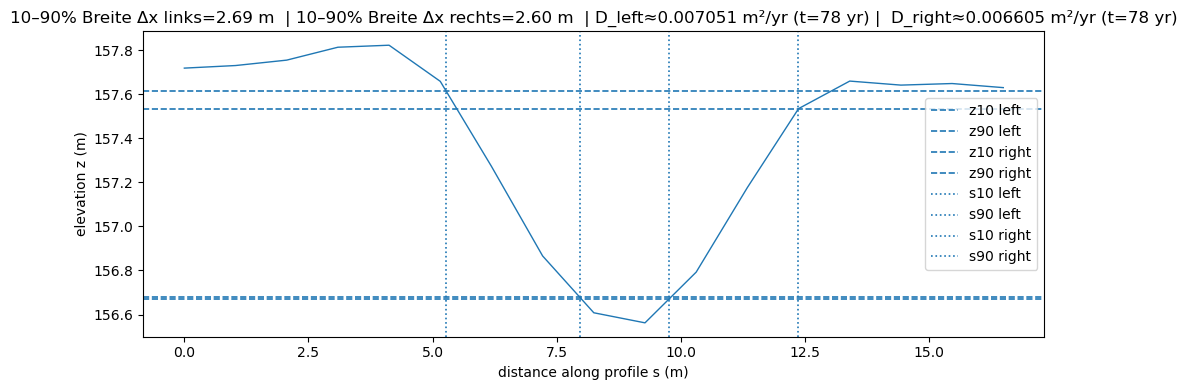

In [10]:
plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1)

# reference levels
plt.axhline(res_left['z10_left'], linestyle='--', label='z10 left')
plt.axhline(res_left['z90_left'], linestyle='--', label='z90 left')
plt.axhline(res_right['z10_right'], linestyle='--', label='z10 right')
plt.axhline(res_right['z90_right'], linestyle='--', label='z90 right')

# mark s10/s90
plt.axvline(res_left['s10_left'], linestyle=':', label='s10 left')
plt.axvline(res_left['s90_left'], linestyle=':', label='s90 left')
plt.axvline(res_right['s10_right'], linestyle=':', label='s10 right')
plt.axvline(res_right['s90_right'], linestyle=':', label='s90 right')

plt.title(f"10–90% Breite Δx links={res_left['dx_10_90_left_m']:.2f} m  | 10–90% Breite Δx rechts={res_right['dx_10_90_right_m']:.2f} m  | D_left≈{res_left['D_left_m2_per_yr']:.4g} m²/yr (t={T_YEARS:g} yr) |  D_right≈{res_right['D_right_m2_per_yr']:.4g} m²/yr (t={T_YEARS:g} yr)")
plt.xlabel('distance along profile s (m)')
plt.ylabel('elevation z (m)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## Optional: Vergleich der 10 % - 90 % Breite mit idealer erf-Form (nur zur Intuition)

Hier wird eine idealisierte erf-Kurve mit derselben 10–90%-Breite überlagert.
Das ist **keine** Kalibrierung, nur eine Plausibilitäts-/Lehrgrafik.

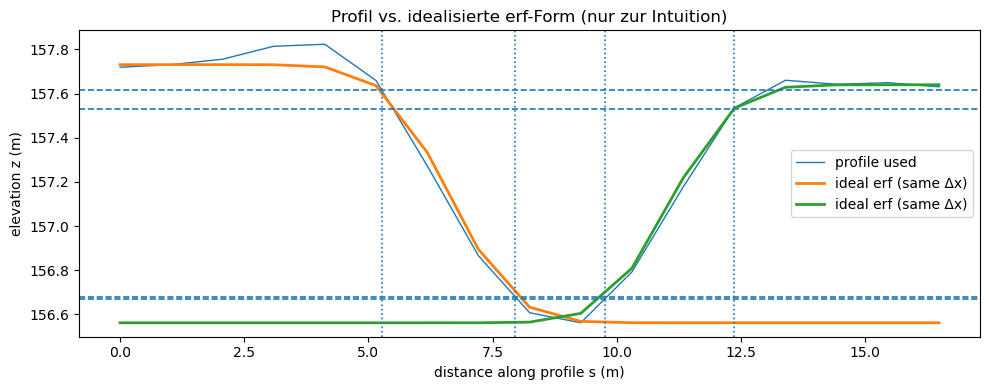

sigma left ≈ 1.05 m
sigma right ≈ 1.02 m


In [11]:
# Build an erf curve that matches the measured 10–90 width
# For the erf step solution: Δx_10-90 = 3.62 * sqrt(D t)
# We can infer sigma = sqrt(2 D t) and plot a normalized erf.
# Create an erf step model

D_left = res_left['D_left_m2_per_yr']
D_right = res_right['D_right_m2_per_yr']
t = T_YEARS
sigma_left = np.sqrt(2 * D_left * t)  # meters # oder: sigma = np.sqrt(2 * (res['dx_10_90_m'] / 3.6)**2) 
sigma_right = np.sqrt(2 * D_right * t)

# Center the model at mid-point between s10 and s90
s0_left = 0.5 * (res_left['s10_left'] + res_left['s90_left'])
s0_right = 0.5 * (res_right['s10_right'] + res_right['s90_right'])

def erf_step_left(s, z_bot, z_top_left, s0, sigma_left):
    u = (s0_left - s) / (np.sqrt(2) * sigma_left) # u = (s0_left - s) / (np.sqrt(2) * sigma) # an links/rechts anpassen
    w = 0.5 * (1.0 + erf(u))
    return z_bot + (z_top_left - z_bot) * w

def erf_step_right (s, z_bot, z_top_right, s0, sigma_right):
    u = (s - s0_right) / (np.sqrt(2) * sigma_right)
    w = 0.5 * (1.0 + erf(u))
    return z_bot + (z_top_right - z_bot) * w

z_model_left = erf_step_left(s, z_bot, res_left['z_top_left'], s0_left, sigma_left)
z_model_right = erf_step_right(s, z_bot, res_right['z_top_right'], s0_right, sigma_right)

plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, label='profile used')
plt.plot(s, z_model_left, linewidth=2, label='ideal erf (same Δx)')
plt.plot(s, z_model_right, linewidth=2, label='ideal erf (same Δx)')
plt.axhline(res_left['z10_left'], linestyle='--')
plt.axhline(res_left['z90_left'], linestyle='--')
plt.axhline(res_right['z10_right'], linestyle='--')
plt.axhline(res_right['z90_right'], linestyle='--')
plt.axvline(res_left['s10_left'], linestyle=':')
plt.axvline(res_left['s90_left'], linestyle=':')
plt.axvline(res_right['s10_right'], linestyle=':')
plt.axvline(res_right['s90_right'], linestyle=':')
plt.title('Profil vs. idealisierte erf-Form (nur zur Intuition)')
plt.xlabel('distance along profile s (m)')
plt.ylabel('elevation z (m)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"sigma left ≈ {sigma_left:.2f} m")
print(f"sigma right ≈ {sigma_right:.2f} m")


In [12]:
erf_step_model_left = erf_step_left # just for later use of the variable
erf_step_model_right = erf_step_right

## 5b) Diffusionsabschätzung aus der Vergrößerung des Kraterdurchmessers mit der Fehlerfunktionslösung (1D Diffusion)

Formel: (Formel r1: Gl. 14; 15; t1: Gl. 15; D: Gl. 11 der Bachelorarbeit)

Annahme 1: Die Position der Wasserscheide entspricht der Position einer festen Höhe auf dem Profil. Das Verhältnis n1D der 90-10-Breite zum Radius der Wasserscheide ist dadurch konstant.

Annahme 2: Die Begrenzung des Materialtransports am Kratertiefpunkt ist vernachlässigbar

Annahme 3: Der Kratertiefpunt verschiebt sich in asymmetrischen Kratern durch die Streckung der Profile mit derselben Diffusion Dt. Die Verschiebung des Fixpunktes des Profils wird jedoch bei der berechnung des Diffusionskoeffizienten nicht berücksichtigt.

In [13]:
r_left = s_bot - s_devide_left
r_right = s_devide_right - s_bot
n_left = dx_left /r_left
n_right = dx_right /r_right

#Calculating the Radius on the areal image with: D_left = D_right (Gl. 14 in der Bachelorarbeit)
def solve_r1_1D(n_left, r_left, n_right, r_right, or_diameter):
    A = n_right**2 - n_left**2
    B = 2 * n_left**2 * or_diameter
    C = n_left**2 * (r_left**2 - or_diameter**2) - n_right**2 * r_right**2

    if n_right == n_left:
        r1_right = (r_right**2 - r_left**2 + or_diameter**2) / (2*or_diameter)
    else:
        if np.isclose(A,0):
            r1_right = -C / B
            if 0 < r1_right < or_diameter:
                r1_left = or_diameter - r1_right
                return [(r1_right, r1_left, r1_left / r1_right)]
            return None

    roots = np.roots([A, B, C])

    
    for r in roots:
        if np.isreal(r) and 0 < r.real < or_diameter:
            r1_right = r.real
            r1_left = or_diameter - r1_right
            return r1_right, r1_left
    return None

results_r1 = solve_r1_1D (n_left, r_left, n_right, r_right, or_diameter)

if results_r1 is not None:
    r1_right, r1_left = results_r1
    print ('r1 links (Luftbild):', r1_left)
    print ('r1 rechts (Luftbild):', r1_right)
else: print ("Keine gültige Lösung")

   
# Calculate D   (Gl. 11 in der Bachelorarbeit)
D_r_left = (((n_left) / 3.624)**2 * (r_left**2 - r1_left**2))/ float(T_YEARS)
D_r_right = (((n_right) / 3.624)**2 * (r_right**2 - r1_right**2))/ float(T_YEARS)

# Calculate t1 und t2 (apparent age)  (Gl. 10 in der Bachelorarbeit)
t1_left = (float(T_YEARS) * n_left**2 * r1_left**2 )/ ((n_left*r_left)**2 - (n_left*r1_left)**2)
t1_right = (float(T_YEARS) * n_right**2 * r1_right**2 )/ ((n_right*r_right)**2 - (n_right*r1_right)**2)
t2_right = t1_right+t
t2_left = t1_left+t

if D_r_left < 0 or D_r_right < 0:
    raise ValueError('Original crater radius (r1) is too big')


print ('r left (DGM):', r_left)
print ('n left:', n_left)
print ('r right (DGM):', r_right)
print ('n right:', n_right)
print ('D from left Radius:', D_r_left)
print ('D from right Radius:', D_r_right)
print ('t1 left (initial apparent age):', t1_left)
print ('t1 right (initial apparent age):', t1_right)
print ('t2 left (apparent age):', t2_left)
print ('t2 right (apparent age):', t2_right)

r1 links (Luftbild): 4.543867586865112
r1 rechts (Luftbild): 3.5998315559764795
r left (DGM): 5.153440988209835
n left: 0.5214999951034464
r right (DGM): 4.122752790567869
n right: 0.630947830577615
D from left Radius: 0.0015693321082097993
D from right Radius: 0.001569332108209799
t1 left (initial apparent age): 272.4386459441408
t1 right (initial apparent age): 250.2995240239971
t2 left (apparent age): 350.4386459441408
t2 right (apparent age): 328.2995240239971


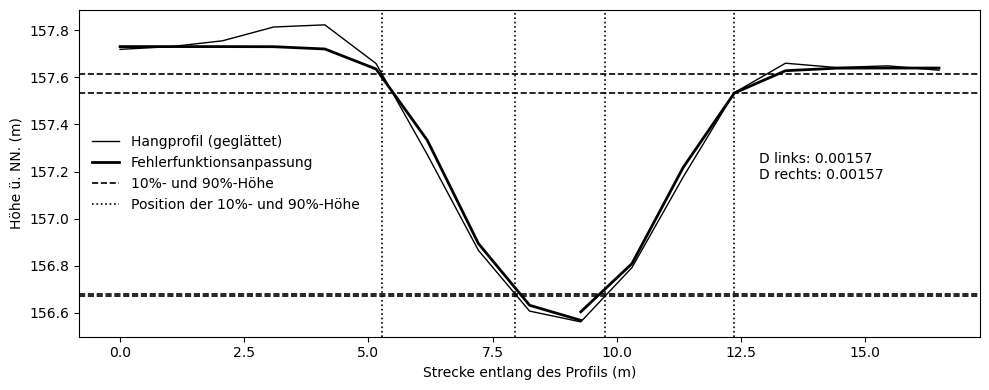

In [14]:
## Profile-fit with calculated values (to test the model)
sigma_1D_left = np.sqrt(2 * D_r_left * (t1_left+t)) 
sigma_1D_right = np.sqrt(2 * D_r_right * (t1_right+t))

z_r1D_left = erf_step_left(s_left, z_bot, res_left['z_top_left'], s0_left, sigma_1D_left)
z_r1D_right = erf_step_right(s_right, z_bot, res_right['z_top_right'], s0_right, sigma_1D_right)

plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, color='black', label='Hangprofil (geglättet)')
plt.plot(s_left, z_r1D_left, linewidth=2, color='black', label='Fehlerfunktionsanpassung')
plt.plot(s_right, z_r1D_right, linewidth=2, color='black')
plt.axhline(res_left['z10_left'], linestyle='--',color='black', label='10%- und 90%-Höhe')
plt.axhline(res_left['z90_left'], linestyle='--',color='black')
plt.axhline(res_right['z10_right'], linestyle='--',color='black')
plt.axhline(res_right['z90_right'], linestyle='--',color='black')
plt.axvline(res_left['s10_left'], linestyle=':',color='black', label='Position der 10%- und 90%-Höhe')
plt.axvline(res_left['s90_left'], linestyle=':',color='black')
plt.axvline(res_right['s10_right'], linestyle=':',color='black')
plt.axvline(res_right['s90_right'], linestyle=':',color='black')
plt.xlabel('Strecke entlang des Profils (m)')
plt.ylabel('Höhe ü. NN. (m)')
plt.legend(loc='best', frameon=False)
plt.text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.5, f"D links: {D_r_left:.5f}\nD rechts: {D_r_right:.5f}", va='center', ha='left')
plt.tight_layout()
#plt.savefig("Erf_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6a) Kratervolumen berechnen

Das Kratervolumen wird berechnet, für einen fiktiven Radialsymmetrischen Krater mit dem Hangprofil das dem linken bzw.  rechten Profil entspricht.
Das Volumen wird für die hier verwendete Profilanpassung verwendet. Alternativ ist eine Anpassung mit der Kratertiefe möglich.

Die berechnung des Volumens ist bis zur Wasserscheide oder bis zum ersten Schnittpunkt des inneren Kraterhangs mit der Referenzhöhe außerhalb des Kraters möglich.

In [15]:
# (Gl. 17 der Bachelorarbeit) numeric approximation with trapezoidal rule
def Cratervolume (s_right2, z_right, s_devide_right2, z_devide_right):
    s = np.asarray(s_right2); z = np.asarray(z_right)
    # find index j where s[j] > s_devide_right, keep upto j-1
    j = np.searchsorted(s, s_devide_right2, side='right')
    s_tr = np.concatenate([s[:j], [s_devide_right2]])
    z_tr = np.concatenate([z[:j], [z_devide_right]])
     
    j = idx = np.argmin(np.abs(s - s_devide_right2))
    s_tr = s[:j+1]
    z_tr = z[:j+1]
    integrand = s_tr * (z_devide_right - z_tr)      
    integrand = np.maximum(integrand, 0)  # optional: positive values only

    ds = np.diff(s_tr)
    if ds.size == 0:
        return 0.0, float(s_devide_right2)
    trapez = 0.5 * (integrand[:-1] + integrand[1:]) * ds
    V = 2.0 * np.pi * np.sum(trapez)
    
    return float(max(V, 0.0))

# Cratervolume with drainage devide as reference level  
V_devide_right = Cratervolume (s_right2, z_right, s_devide_right2, z_devide_right)
V_devide_left = Cratervolume (s_left2, z_left2, s_devide_left2, z_devide_left)
print ('Volume to right devide:', V_devide_right,'Volume to left devide:', V_devide_left) 

Volume to right devide: 14.817911795705376 Volume to left devide: 36.03420979022575


## 6b) Berechung von D aus 2D Diffusionsmodell mit Radiusausbreitung (90%-Radius) mit der Wasserscheide als Referenzhöhe

Referenzhöhe: Wasserscheide

Methode: Berechnung aus der Ausbreitung des 90%-Radius mit berechnetem Volumen 
        (Alternative Möglichkeit: nutzung der Höhendifferenz anstatt des Volumens (Abschnitt 3.3 der
        Bachelorarbeit). )

Formel: D = (r2^2-r1^2)/(Pi * W_-1(deltaZ0,1 * r2^2 * Pi / V ) t)
        (D: Gl. 27: r1: Gl. 28; 29 und t1: Gl. 26 aus der Bachelorarebeit)

Annahme 1: Die Position der Wasserscheide entspricht der Position einer festen Höhe auf dem Profil. Das Verhältnis n2D des 90%-Radius zum Radius der Wasserscheide ist dadurch konstant.

Annahme 2: Die Höhe der Wassrerscheide entspricht der Höhe einer Unendlichen Ebene (Loch ohne umgelagertes Material)

Annahme 3: Das Kratervolumen bleibt konstant durch vernachlässigung des umgelagerten Materials. Das Loch breitet sich durch diffusion aus.

Annahme 4: Der Kratertiefpunt verschiebt sich in asymmetrischen Kratern durch die Streckung der Profile mit derselben Diffusion Dt. Die Verschiebung des Fixpunktes des Profils wird bei der Berechnung von r1, jedoch nicht bei der berechnung des Diffusionskoeffizienten nicht berücksichtigt. 

In [16]:
zr_right = res_right['z_top_right'] # reference level outside of the crater
zr_left = res_left['z_top_left'] 

# choose reference level (z_devide_ or zr_) 
zmax_right = z_devide_right 
zmax_left = z_devide_left 

# calculate D (Gl. 28)
def D_from_2D_model(s_devide_right2, s_devide_left2, V_devide_right, V_devide_left, zmax_right = z_devide_right, zmax_left = z_devide_left):
    # Weitere parameter n, C, bestimmen
    n_2D_right = (res_right['s90_right']-s_bot)/s_devide_right2
    n_2D_left = (s_bot - res_left['s90_left'])/s_devide_left2
    Cr = zmax_right-res_right['z90_right'] # Höhendifferenz für festen Punkt mit der Höhe 90%
    Cl = zmax_left-res_left['z90_left'] 
    Lir = - (Cr*(n_2D_right*s_devide_right2)**2*np.pi)/V_devide_right #Inhalt der Lambert w Funktion
    Lil = - (Cl*(n_2D_left*s_devide_left2)**2*np.pi)/V_devide_left
    wl = n_2D_left**2 / lambertw(Lil, k=-1)
    wr = n_2D_right**2 / lambertw(Lir, k=-1)
    print (n_2D_right,n_2D_left,Cr,Cl,s_devide_right2,s_devide_left2,Lir,Lil)
    if np.isreal(wl) == True and np.isreal(wr) == True:
        wl = wl.real
        wr = wr.real
    else:
        if np.isreal(wl) == False:
            raise ValueError('No real Solution for wl');
        if np.isreal(wr) == False:
            raise ValueError('No real Solution for wr')


    results_r1_2D = solve_r1_1D (np.sqrt(-wl), r_left, np.sqrt(-wr), r_right, or_diameter)

    if results_r1_2D is not None:
        r1_2D_right, r1_2D_left = results_r1_2D
        print ('r1 links:', r1_2D_left)
        print ('r1 rechts:', r1_2D_right)
    else: print ("Keine gültige Lösung")

    t1_2D_right = T_YEARS*r1_2D_right**2 / (r_right**2-r1_2D_right**2) 
    t2_2D_right = t1_2D_right + T_YEARS
    t1_2D_left = T_YEARS*r1_2D_left**2 / (r_left**2-r1_2D_left**2) 
    t2_2D_left = t1_2D_left + T_YEARS

    D_r2D_right = - (n_2D_right*s_devide_right2)**2 * wr/ (np.pi*t2_2D_right*n_2D_right**2) #wr
    D_r2D_left = - (n_2D_left*s_devide_left2)**2 * wl/ (np.pi*t2_2D_left*n_2D_left**2) #wl

    return float(r1_2D_right),float(r1_2D_left),float(t1_2D_right),float(t2_2D_right),float(t1_2D_left),float(t2_2D_left),float(D_r2D_right),float(D_r2D_left),float(n_2D_right),float(n_2D_left),float(Cr),float(Cl)

# calculate D, r1, t1 for the drainage devide as reference level
r1_2D_right, r1_2D_left, t1_2D_right, t2_2D_right, t1_2D_left, t2_2D_left, D_r2D_right, D_r2D_left, n_2D_right, n_2D_left, Cr, Cl = D_from_2D_model(s_devide_right2, s_devide_left2, V_devide_right, V_devide_left, zmax_right = z_devide_right, zmax_left = z_devide_left)
t2_2D_right = t1_2D_right+t
t2_2D_left = t1_2D_left+t
print ('t1_2D_right:',t1_2D_right)
print ('t2_2D_right:',t2_2D_right)
print ('t1 2D left:', t1_2D_left)
print ('t2 2D left:', t2_2D_left)
print ('D right from 2D model:', D_r2D_right)
print ('D left from 2D model:', D_r2D_left)
print ('n_2D_left:',n_2D_left)
print ('n_2D_right:',n_2D_right)
#print ('s_devide_right2:',s_devide_right2)
#print ('s_devide_left2:',s_devide_left2)
#print ('V_devide_right:',V_devide_right)
#print ('V_devide_right:',V_devide_right)
print ('Cl:',Cl)
print ('Cr:',Cr)
print ('Test: Z(0):', V_devide_right/(4*np.pi*D_r2D_right*t2_2D_right))

0.747897258665512 0.7766269852923409 0.12815392630434985 0.20911372593459987 4.122752790567869 5.153440988209835 -0.2583171587234761 -0.2920363948795683
r1 links: 4.71814127232526
r1 rechts: 3.42555787051633
t1_2D_right: 173.92148717434546
t2_2D_right: 251.92148717434546
t1 2D left: 404.07439486973016
t2 2D left: 482.07439486973016
D right from 2D model: 0.005743887767171331
D left from 2D model: 0.005743887767171346
n_2D_left: 0.7766269852923409
n_2D_right: 0.747897258665512
Cl: 0.20911372593459987
Cr: 0.12815392630434985
Test: Z(0): 0.8149031272556352


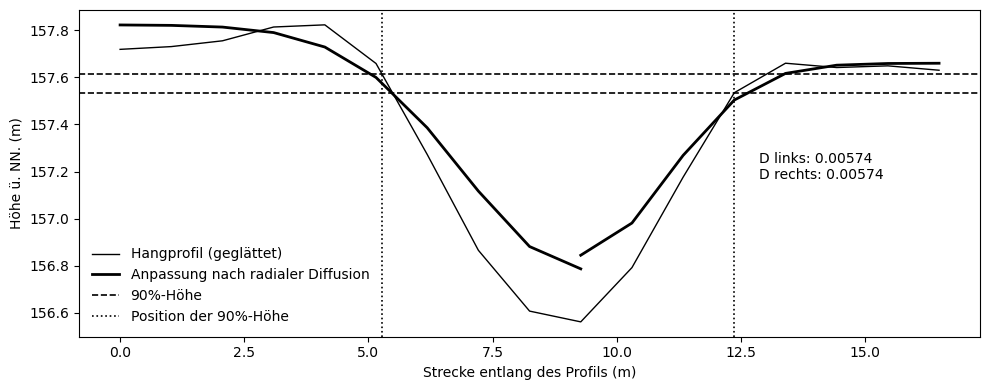

In [17]:
## Hillslope-fit with calculated parameters from 2D-model with drainage devide as reference level
def fit_2D (V_devide_right, s_right, D_r2D_right, z_bot, z_devide_right, t2_2D_right):
    w = -(V_devide_right / (4*np.pi * D_r2D_right * t2_2D_right)) * np.exp(- (s_right)**2/(4*D_r2D_right*t2_2D_right))
    return z_devide_right  + w

z_2D_fit_right = fit_2D (V_devide_right, s_right-s_bot, D_r2D_right, z_bot, z_devide_right, t2_2D_right) #z_devide_right anstatt zr_right
z_2D_fit_left = fit_2D (V_devide_left, s_bot-s_left2, D_r2D_left, z_bot, z_devide_left, t2_2D_left)


plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, color='black', label='Hangprofil (geglättet)')
plt.plot(s_right, z_2D_fit_right, linewidth=2, color='black', label='Anpassung nach radialer Diffusion')
plt.plot(s_left, z_2D_fit_left, linewidth=2,color='black')
plt.axhline(res_right['z90_right'], linestyle='--',color='black', label='90%-Höhe')
plt.axhline(res_left['z90_left'], linestyle='--',color='black')
plt.axvline(res_right['s90_right'], linestyle=':',color='black', label='Position der 90%-Höhe')
plt.axvline(res_left['s90_left'], linestyle=':',color='black')
plt.xlabel('Strecke entlang des Profils (m)')
plt.ylabel('Höhe ü. NN. (m)')
plt.legend(loc='best', frameon=False)
plt.text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.5, f"D links: {D_r2D_left:.5f}\nD rechts: {D_r2D_right:.5f}", va='center', ha='left')
plt.tight_layout()
#plt.savefig("2D_devide_90.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6c) Berechung von D aus 2D Diffusionsmodell mit Radiusausbreitung (90%-Radius) mit der Referenzhöhe außerhalb des Kraters

Referenzhöhe: außerhalb des Kraters

Methode: Berechnung aus der Ausbreitung des 90%-Radius mit berechnetem Volumen 
        (Alternative Möglichkeit: nutzung der Höhendifferenz anstatt des Volumens (Abschnitt 3.3 der
        Bachelorarbeit). )

Formel: D = (r2^2-r1^2)/(Pi * W_-1(deltaZ0,1 * r2^2 * Pi / V ) t)
        (D: Gl. 27: r1: Gl. 28; 29 und t1: Gl. 26 aus der Bachelorarebeit)

Annahme 1: Die Position der Wasserscheide entspricht der Position einer festen Höhe auf dem Profil. Das Verhältnis n2D des 90%-Radius zum Radius der Wasserscheide ist dadurch konstant.

Annahme 2: Die Höhe der Wassrerscheide entspricht der Höhe einer Unendlichen Ebene (Loch ohne umgelagertes Material)

Annahme 3: Das Kratervolumen bleibt konstant durch vernachlässigung des umgelagerten Materials. Das Loch breitet sich durch diffusion aus.

Annahme 4: Der Kratertiefpunt verschiebt sich in asymmetrischen Kratern durch die Streckung der Profile mit derselben Diffusion Dt. Die Verschiebung des Fixpunktes des Profils wird bei der Berechnung von r1, jedoch nicht bei der berechnung des Diffusionskoeffizienten nicht berücksichtigt. 

In [18]:
# first crossing the reference level by the inner craterslope
def crossing_s(s_right, z_right_for_analysis, target):
        # Schnittpunkt des Hangprofils mit der Referenzhöhe
        ss = s_right.copy()
        zz = z_right_for_analysis.copy()
        mm = np.isfinite(zz)
        zz = zz[mm]
        ss = ss[mm]
        d = zz - target
        sign = np.sign(d)
        # indices where sign changes
        idx = np.where(sign[:-1] * sign[1:] <= 0)[0]
        if len(idx) == 0:
            # fallback: nearest point
            j = int(np.nanargmin(np.abs(d)))
            return float(ss[j])
        # choose crossing closest to mid-profile (often the rim is central)
        mid_right = 0.5 * (ss[0] + ss[-1]) #mid_right = 0.5 * (ss[0] + ss[-1])
        candidates = []
        for i in idx:
            s0, s1 = ss[i], ss[i+1]
            z0, z1 = zz[i], zz[i+1]
            if z1 == z0:
                sc = 0.5 * (s0 + s1)
            else:
                sc = s0 + (target - z0) * (s1 - s0) / (z1 - z0)
            candidates.append(sc)
        candidates = np.array(candidates)
        return float(candidates[np.argmin(np.abs(candidates - mid_right))])
    
s_star_right = crossing_s(s_right, z_right_for_analysis, zr_right)
s_star_left = crossing_s(s_left, z_left_for_analysis, zr_left)

# cratervolume to reference level outside of the crater
V_ref_right = Cratervolume (s_right2, z_right, s_star_right-s_bot, zr_right)
V_ref_left = Cratervolume (s_left2, z_left2, s_bot-s_star_left, zr_left)

# calculate D, r1, t1 for the drainage devide as reference level
if zr_left>res_left['z90_left'] or zr_right>res_right['z90_right']:   
    r1_2D_ref_right, r1_2D_ref_left, t1_2D_ref_right, t2_2D_ref_right, t1_2D_ref_left, t2_2D_ref_left, D_r2D_ref_right, D_r2D_ref_left, n_2D_ref_right, n_2D_ref_left, Cr_ref, Cl_ref = D_from_2D_model(s_devide_right2, s_devide_left2, V_ref_right, V_ref_left, zmax_right = zr_right, zmax_left = zr_left)
else: r1_2D_ref_right, r1_2D_ref_left, t1_2D_ref_right, t2_2D_ref_right, t1_2D_ref_left, t2_2D_ref_left, D_r2D_ref_right, D_r2D_ref_left, n_2D_ref_right, n_2D_ref_left, Cr_ref, Cl_ref = (False,)*12

print ('t1_2D_right:',t1_2D_ref_right)
print ('t1 2D left:', t2_2D_ref_right)
print ('D right from 2D model to ref margin:', D_r2D_ref_right)
print ('D left from 2D model to ref margin:', D_r2D_ref_left)
print ('n_2D_ref_left:',n_2D_ref_left)
print ('n_2D_ref_right:',n_2D_ref_right)
print ('Cl_ref:',Cl_ref)
print ('Cr_ref:',Cr_ref)
print ('Volume right :', V_ref_right,'Volume left :', V_ref_left) 
print ('Schnittpunkt links:', s_star_left, 'zr:', zr_left)
print ('Schnittpunkt rechts:', s_star_right, 'zr:', zr_right)

0.747897258665512 0.7766269852923409 0.10772872924803778 0.11682856968471356 4.122752790567869 5.153440988209835 -0.22983412103865067 -0.2022722440960914
r1 links: 4.65438545266646
r1 rechts: 3.4893136901751305
t1_2D_right: 196.9550819688544
t1 2D left: 274.9550819688544
D right from 2D model to ref margin: 0.004773279382434137
D left from 2D model to ref margin: 0.004773279382434145
n_2D_ref_left: 0.7766269852923409
n_2D_ref_right: 0.747897258665512
Cl_ref: 0.11682856968471356
Cr_ref: 0.10772872924803778
Volume right : 13.999914289056958 Volume left : 29.065795119363973
Schnittpunkt links: 4.702721416929831 zr: 157.73057120186937
Schnittpunkt rechts: 13.230719419996344 zr: 157.6395727975027


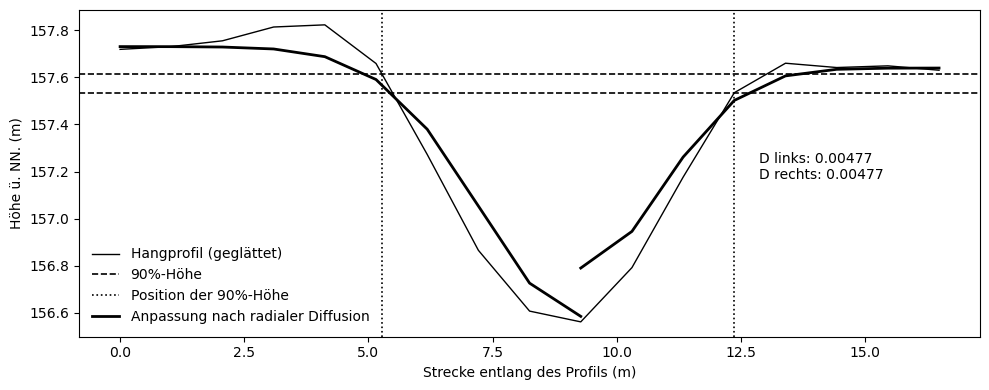

In [19]:
## Hillslope-fit with calculated parameters from 2D-model with reference level outside of the crater
plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, color='black', label='Hangprofil (geglättet)')
#plt.axhline(zr_right, linestyle='--')
#plt.axhline(zr_left, linestyle='--')
#plt.axvline(z_star_right, linestyle=':', color='black')
#plt.axvline(z_star_left, linestyle=':', color='black')
plt.axhline(res_right['z90_right'], linestyle='--', color='black',label='90%-Höhe')
plt.axhline(res_left['z90_left'], linestyle='--', color='black')
plt.axvline(res_right['s90_right'], linestyle=':', color='black', label='Position der 90%-Höhe')
plt.axvline(res_left['s90_left'], linestyle=':', color='black')

if zr_left>res_left['z90_left'] or zr_right>res_right['z90_right']:   
    z_ref_2D_fit_right = fit_2D (V_ref_right, s_right-s_bot, D_r2D_ref_right, z_bot, zr_right, t2_2D_ref_right) #z_devide_right anstatt zr_right
    z_ref_2D_fit_left = fit_2D (V_ref_left, s_bot-s_left2, D_r2D_ref_left, z_bot, zr_left, t2_2D_ref_left)
    plt.plot(s_right, z_ref_2D_fit_right, linewidth=2, color='black', label='Anpassung nach radialer Diffusion')
    plt.plot(s_left, z_ref_2D_fit_left, linewidth=2, color='black')
    
plt.xlabel('Strecke entlang des Profils (m)')
plt.ylabel('Höhe ü. NN. (m)')
plt.legend(loc='best', frameon=False)
plt.text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.5, f"D links: {D_r2D_ref_left:.5f}\nD rechts: {D_r2D_ref_right:.5f}", va='center', ha='left')
plt.tight_layout()
#plt.savefig("2D_ref_90.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6d) Berechung von D aus 2D Diffusionsmodell mit Radiusausbreitung mit least squares fit an das Profil und mit der Referenzhöhe außerhalb des Kraters (mathematisch nicht exakt)

Referenzhöhe: außerhalb des Kraters

Methode: Berechnung aus der Ausbreitung des der Wasserscheide mit least squares fit mit berechnetem Volumen 
        (Alternative Möglichkeit: nutzung der Höhendifferenz anstatt des Volumens (Abschnitt 3.3 der
        Bachelorarbeit). )
        Mathematisch nicht exakt da D_left = D_right nicht exakt zutrifft (berechnung von r1) wenn D aus zwei
        getrennten Hangprofilanpassungen berechnet wird. r1 und t1 werden aus der mathematisch exakten Berechnung
        anhand des 90%-Radius verwendet.

Formel: Anpassung von Z(r) = Zref - (V/(4Pi Dt) * exp(-r^2(4Dt))) (Gl. 6 der Bachelorarbeit)

Annahme 1: Die Position der Wasserscheide entspricht der Position einer festen Höhe auf dem Profil. Das Verhältnis n2D des 90%-Radius zum Radius der Wasserscheide ist dadurch konstant.

Annahme 2: Die Höhe der Wassrerscheide entspricht der Höhe einer Unendlichen Ebene (Loch ohne umgelagertes Material)

Annahme 3: Das Kratervolumen bleibt konstant durch vernachlässigung des umgelagerten Materials. Das Loch breitet sich durch diffusion aus.

Annahme 4: Der Kratertiefpunt verschiebt sich in asymmetrischen Kratern durch die Streckung der Profile mit derselben Diffusion Dt. Die Verschiebung des Fixpunktes des Profils wird bei der Berechnung von r1, jedoch nicht bei der berechnung des Diffusionskoeffizienten nicht berücksichtigt.

In [20]:
# 2D least squares fit to calculate D
def D_and_V_2Dfit(s_right, z_right, z_top, V_ref_right, t2_2D_right):
    # if V is known:
    V = V_ref_right  

    # start value
    tau0 = np.median(s_right**2//4.0)
    V_guess = z_right[-1] * 4*np.pi*tau0

    def z_model_2D (s_right, tau, V):
        return z_top-(V / (4*np.pi*tau) * np.exp(-s_right**2/(4*tau)))
    
    popt, pcov = curve_fit(z_model_2D, s_right, z_right, p0=[tau0, V_guess], bounds=(1e-12, np.inf))
    tau_est_right = popt[0]
    tau_err_right = np.sqrt(np.diag(pcov))[0]
    D_2Dfit_right = tau_est_right / t2_2D_right
    
    return D_2Dfit_right

if zr_left>res_left['z90_left'] or zr_right>res_right['z90_right']:
    D_2Dfit_right = D_and_V_2Dfit(s_right2, z_right_for_analysis2-z_bot, zr_right - z_bot, V_ref_right, t2_2D_ref_right)
    D_2Dfit_left = D_and_V_2Dfit(s_left2, z_left_for_analysis2-z_bot, zr_left - z_bot, V_ref_left, t2_2D_ref_left)
else: 
    D_2Dfit_right, D_2Dfit_left = False, False
    print('Referenzhöhe außerhalb des Kraters kann nicht verwendet werden, da sie zu niedrig ist. Das Profil ist zu lang oder die Morphologie außerhalb des kraters nicht flach genug.')
print ('D_2Dfit_right:', D_2Dfit_right)
print ('D_2Dfit_left:', D_2Dfit_left)




D_2Dfit_right: 0.004158059755444131
D_2Dfit_left: 0.005048738639876803


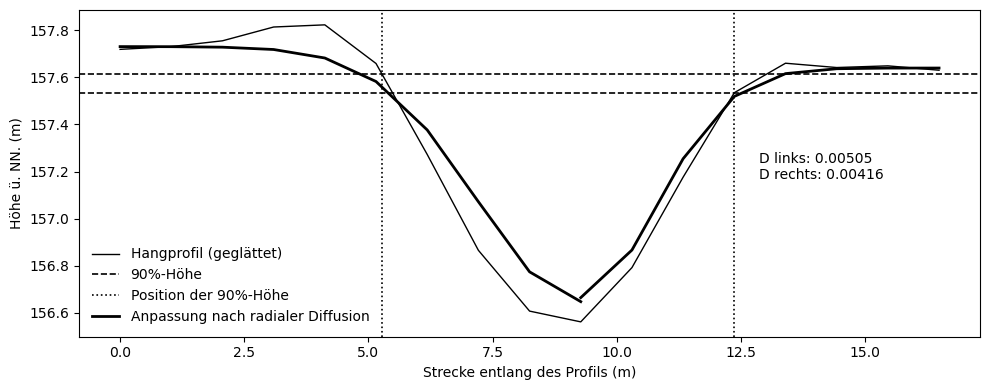

In [21]:
#Plot 2D least squares fits with calculated D, V_ref, t2 with reference level outside of the crater
plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, color='black',label='Hangprofil (geglättet)')
#plt.axhline(zr_right, linestyle='--', color='black')
#plt.axhline(zr_left, linestyle='--', color='black')
#plt.axvline(s_star_right, linestyle=':', color='black')
#plt.axvline(s_star_left, linestyle=':', color='black')
plt.axhline(res_right['z90_right'], linestyle='--', color='black', label='90%-Höhe')
plt.axhline(res_left['z90_left'], linestyle='--', color='black')
plt.axvline(res_right['s90_right'], linestyle=':', color='black', label='Position der 90%-Höhe')
plt.axvline(res_left['s90_left'], linestyle=':', color='black')

if zr_left>res_left['z90_left'] or zr_right>res_right['z90_right']:
    z_ref_2D_fit_right = fit_2D (V_ref_right, s_right-s_bot, D_2Dfit_right, z_bot, zr_right, t2_2D_ref_right) #z_devide_right anstatt zr_right
    z_ref_2D_fit_left = fit_2D (V_ref_left, s_bot-s_left2, D_2Dfit_left, z_bot, zr_left, t2_2D_ref_left)

    plt.plot(s_right, z_ref_2D_fit_right, linewidth=2, color='black', label='Anpassung nach radialer Diffusion')
    plt.plot(s_left, z_ref_2D_fit_left, linewidth=2, color='black')

plt.xlabel('Strecke entlang des Profils (m)')
plt.ylabel('Höhe ü. NN. (m)')
plt.legend(loc='best', frameon=False)
plt.text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.5, f"D links: {D_2Dfit_left:.5f}\nD rechts: {D_2Dfit_right:.5f}", va='center', ha='left')
plt.tight_layout()
#plt.savefig("2D_ref_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6d) Berechung von D aus 2D Diffusionsmodell mit Radiusausbreitung mit least squares fit an das Profil und mit der Wasserscheide als Referenzhöhe(mathematisch nicht exakt)

Referenzhöhe: Wasserscheide

Methode: Berechnung aus der Ausbreitung des der Wasserscheide mit least squares fit mit berechnetem Volumen 
        (Alternative Möglichkeit: nutzung der Höhendifferenz anstatt des Volumens (Abschnitt 3.3 der
        Bachelorarbeit). )
        Mathematisch nicht exakt da D_left = D_right nicht exakt zutrifft (berechnung von r1) wenn D aus zwei
        getrennten Hangprofilanpassungen berechnet wird. r1 und t1 werden aus der mathematisch exakten Berechnung
        anhand des 90%-Radius verwendet.

Formel: Anpassung von Z(r) = Zref - (V/(4Pi Dt) * exp(-r^2(4Dt))) (Gl. 6 der Bachelorarbeit)

Annahme 1: Die Position der Wasserscheide entspricht der Position einer festen Höhe auf dem Profil. Das Verhältnis n2D des 90%-Radius zum Radius der Wasserscheide ist dadurch konstant.

Annahme 2: Die Höhe der Wassrerscheide entspricht der Höhe einer Unendlichen Ebene (Loch ohne umgelagertes Material)

Annahme 3: Das Kratervolumen bleibt konstant durch vernachlässigung des umgelagerten Materials. Das Loch breitet sich durch diffusion aus.

Annahme 4: Der Kratertiefpunt verschiebt sich in asymmetrischen Kratern durch die Streckung der Profile mit derselben Diffusion Dt. Die Verschiebung des Fixpunktes des Profils wird bei der Berechnung von r1, jedoch nicht bei der berechnung des Diffusionskoeffizienten nicht berücksichtigt. 

In [22]:
#2D least squares fits with calculated D, V_ref, t2 with drainage devide as reference level 
sel_right = (s_right2 <= s_devide_right-s_bot) & np.isfinite(z_right_for_analysis2)
sel_left = (s_left2 <= s_bot-s_devide_left) & np.isfinite(z_left_for_analysis2)
if sel_right.sum() < 4 or sel_left.sum() < 4: #30
    raise ValueError('Fit window too small or too many NaNs. Increase window_m or improve profile.')

sw_right = s_right2[sel_right]
zw_right = z_right2[sel_right]
sw_left = s_left2[sel_left]
zw_left = z_left2[sel_left]

D_2Dfit_devide_right = D_and_V_2Dfit(sw_right, zw_right-z_bot, deltaz_right, V_devide_right, t2_2D_right)
D_2Dfit_devide_left = D_and_V_2Dfit(sw_left, zw_left-z_bot, deltaz_left, V_devide_left, t2_2D_left)
print ('D right aus fit bis zur devide:',D_2Dfit_devide_right)
print ('D left aus fit bis zur devide:',D_2Dfit_devide_left)

D right aus fit bis zur devide: 0.004505155273989233
D left aus fit bis zur devide: 0.005129641193330684


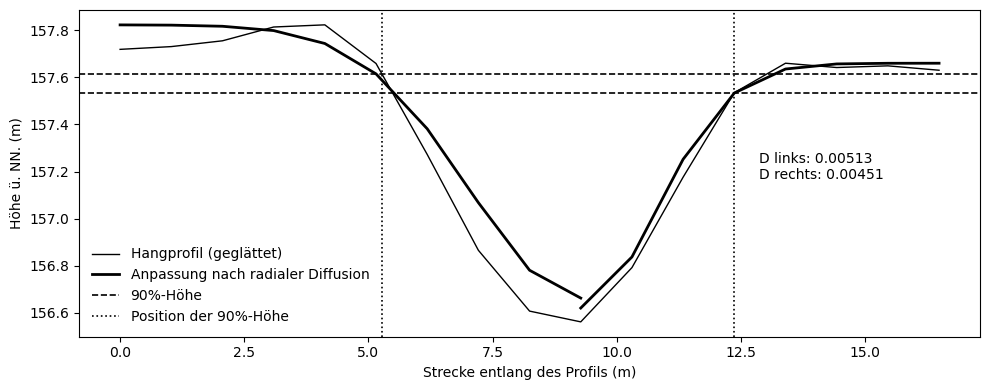

In [23]:
#Plot 2D least squares fit to devide with calculated D, V und t2 with drainage devide as reference level
z_devide_2D_fit_right = fit_2D (V_devide_right, s_right-s_bot, D_2Dfit_devide_right, z_bot, z_devide_right, t2_2D_right) #z_devide_right anstatt zr_right
z_devide_2D_fit_left = fit_2D (V_devide_left, s_bot-s_left2, D_2Dfit_devide_left, z_bot, z_devide_left, t2_2D_left)
plt.figure(figsize=(10,4))
plt.plot(s, z_for_analysis, linewidth=1, color='black',label='Hangprofil (geglättet)')
plt.plot(s_right, z_devide_2D_fit_right, linewidth=2,color='black', label='Anpassung nach radialer Diffusion')
plt.plot(s_left, z_devide_2D_fit_left, linewidth=2,color='black')
#plt.axhline(zr_right, linestyle='--',color='black')
#plt.axhline(zr_left, linestyle='--',color='black')
#plt.axvline(s_star_right, linestyle=':',color='black')
#plt.axvline(s_star_left, linestyle=':',color='black')
plt.axhline(res_right['z90_right'], linestyle='--',color='black', label='90%-Höhe')
plt.axhline(res_left['z90_left'], linestyle='--',color='black')
plt.axvline(res_right['s90_right'], linestyle=':',color='black', label='Position der 90%-Höhe')
plt.axvline(res_left['s90_left'], linestyle=':',color='black')

plt.xlabel('Strecke entlang des Profils (m)',color='black')
plt.ylabel('Höhe ü. NN. (m)')
plt.legend(loc='best', frameon=False)
plt.text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.5, f"D links: {D_2Dfit_devide_left:.5f}\nD rechts: {D_2Dfit_devide_right:.5f}", va='center', ha='left')
plt.tight_layout()
#plt.savefig("2D_devide_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7) Plots für die Bachelorarbeit / Publikation

## 7a) Hangprofilbeschreibung (Abb. 3)

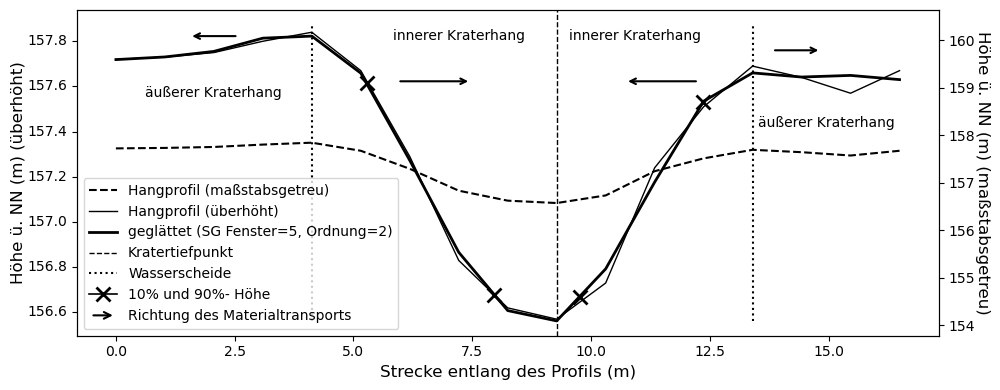

In [24]:
# Hillslope profile plot for chapter 2 "Beschreibung der Hangprofile / Kratermorphologie"
fig, ax = plt.subplots(figsize=(10,4))
#ax.plot(s, z)
plt.plot(s, z, linewidth=1, linestyle='-',color='black', label='Hangprofil (überhöht)')
if z_smooth is not None:
    plt.plot(s, z_use, linewidth=2, linestyle='-', color='black', label=f'geglättet (SG Fenster={wl}, Ordnung={SG_POLYORDER})')

# Profile without vertical exaggeration
Skala = 0.5
ax2 = ax.twinx()          # teilt x‑Achse, eigene y‑Achse
ax2.plot(s, z, color='k', linestyle='--', label='Hangprofil (maßstabsgetreu)', linewidth = 1.5)
#ax2.plot(s_bot, z_devide_left-(1/Skala*), Marker='.', markersize=0.01)
ax2.set_ylabel('Höhe ü. NN (m) (maßstabsgetreu)', color='k', fontsize=12, rotation=270)
#ax.tick_params(axis='y', labelcolor='k')
ax2.yaxis.label.set_color('k')
ax2.yaxis.set_label_coords(1.06, 0.5)
ax2.set_aspect('equal', adjustable='datalim')

# Axis scale with vertical exaggeration
ax.set_ylabel('Höhe ü. NN (m) (überhöht)', color='k', fontsize=12)
#ax.tick_params(axis='y', labelcolor='k')
ax.yaxis.set_label_coords(-0.06, 0.5) 
ax.yaxis.set_tick_params(pad=32)
ax.set_xlabel('Strecke entlang des Profils (m)', color='k', fontsize=12)

for lbl in ax.get_yticklabels():
    lbl.set_verticalalignment('center')  # oder 'center'
    lbl.set_horizontalalignment('left')  # justiert Abstand zur Achse
    lbl.set_color('k')

# Craterbottom,  drainage devides
ax.axvline(s_bot, linestyle='--', color='black', linewidth=1, label='Kratertiefpunkt')
#plt.axvline(s_devide_left, linestyle=':', color='black',linewidth=1.5, label='Wasserscheide')
ax.plot([s_devide_left, s_devide_left], [z_bot, z_devide_left+0.05], linestyle=':', color='black',linewidth=1.5)
#plt.axvline(s_devide_right, linestyle=':', color='black', linewidth=1.5)
ax.plot([s_devide_right, s_devide_right], [z_bot, z_devide_left+0.05], linestyle=':', color='black', linewidth=1.5, label='Wasserscheide')

# 4 Arrows for material flow direction
xp, yp = s_bot- 0.35*(s_bot-s_devide_left), z_devide_left-0.2
arrow_length = 0.3*(s_bot-s_devide_left)  # arrow length in x-units (m)
xt, yt = xp - arrow_length, yp   # Start x (arrow to the right)
ax.annotate('', xy=(xp, yp), xytext=(xt, yt),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', mutation_scale=10))

xp2, yp2 = s_bot + (0.35)*(s_devide_right-s_bot), z_devide_left-0.2
xt2, yt2 = xp2 + arrow_length, yp2  
ax.annotate('', xy=(xp2, yp2), xytext=(xt2, yt2),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', mutation_scale=10))

xp3, yp3 = s_devide_left - 0.5*(s_bot-s_devide_left), z_devide_left
arrow_length3 = -0.2*(s_bot-s_devide_left)  # arrow length in x-units (m)
xt3, yt3 = xp3 - arrow_length3, yp3  
ax.annotate('', xy=(xp3, yp3), xytext=(xt3, yt3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', mutation_scale=10))

xp3, yp3 = s_devide_right + (-0.35)*(s_bot-s_devide_right), z_devide_right+0.1
xt3, yt3 = xp3 + arrow_length3, yp3   
ax.annotate('', xy=(xp3, yp3), xytext=(xt3, yt3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', label='Richtung des Materialtransports', mutation_scale=10))

# 10%- and 90%-hight markers
z9010_handle = ax.plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=10, markeredgewidth=2)
ax.plot(res_right['s90_right'], res_right['z90_right'], marker='x', color='k', markersize=10, markeredgewidth=2)
ax.plot(res_left['s10_left'], res_left['z10_left'], marker='x', color='k', markersize=10, markeredgewidth=2)
ax.plot(res_right['s10_right'], res_right['z10_right'], marker='x', color='k', markersize=10, markeredgewidth=2)

# arrow proxy to put the arrow in the legend
class ArrowProxy:
    """Leerobjekt als eindeutiger Typ für den Pfeil-Proxy."""
    def __init__(self, linewidth=1.5, color='black', arrowstyle='-|>', mutation_scale=10):
        self.linewidth = linewidth
        self.color = color
        self.arrowstyle = arrowstyle
        self.mutation_scale = mutation_scale

class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        cy = ydescent + height/2
        x0 = xdescent + 0.05*width
        x1 = xdescent + 0.95*width
        patch = FancyArrowPatch((x0, cy), (x1, cy),
                                arrowstyle=orig_handle.arrowstyle,
                                mutation_scale=orig_handle.mutation_scale,
                                linewidth=orig_handle.linewidth,
                                color=orig_handle.color,
                                transform=trans)
        return [patch]

# Hillslope labels
ax.text(s_bot-(s_bot-s_devide_left)*0.4, z_devide_left, 'innerer Kraterhang', va='center', ha='center', fontsize=10)
ax.text(s_bot+(s_devide_right-s_bot)*0.4, z_devide_left, 'innerer Kraterhang', va='center', ha='center', fontsize=10)
ax.text(s_devide_left*0.5, z_devide_left-(z_devide_left-z_bot)*0.2, 'äußerer Kraterhang', va='center', ha='center', fontsize=10)
ax.text(s[-1]-(s[-1]-s_devide_right)*0.5, z_devide_right-(z_devide_right-z_bot)*0.2, 'äußerer Kraterhang', va='center', ha='center', fontsize=10)

#Handle for 10%-90%-Höhe
h4 = Line2D([0], [0], color='black', linewidth=1.0, marker='x', markersize=10, markeredgewidth=2, linestyle='None', label='10%- und 90%-Höhe')

# get existing handles/labels
handles, labels = ax.get_legend_handles_labels()
handles = list(handles)+z9010_handle; labels = list(labels)+['10% und 90%- Höhe']

# Add Proxy-Arrow (no Line2D!):
arrow_proxy = ArrowProxy(linewidth=1.5, color='black', arrowstyle='->', mutation_scale=12)
handles.append(arrow_proxy); labels.append('Richtung des Materialtransports')

# Legend
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax.legend(lines2 + handles, labels2 + labels, handler_map={ArrowProxy: HandlerArrow()}, loc='best', fontsize=10, frameon=True)
leg.set_zorder(1000)
leg.get_frame().set_zorder(1000)

# plot and save
plt.tight_layout()
plt.xlabel('Strecke entlang des Profils (m)', fontsize=10)
#plt.ylabel('Höhe ü. NN. (m)', fontsize=10)
fig.savefig("Hangprofil.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7b) Hangprofilanpassungen aller 5 Methoden im Vergleich (Abb. 6)

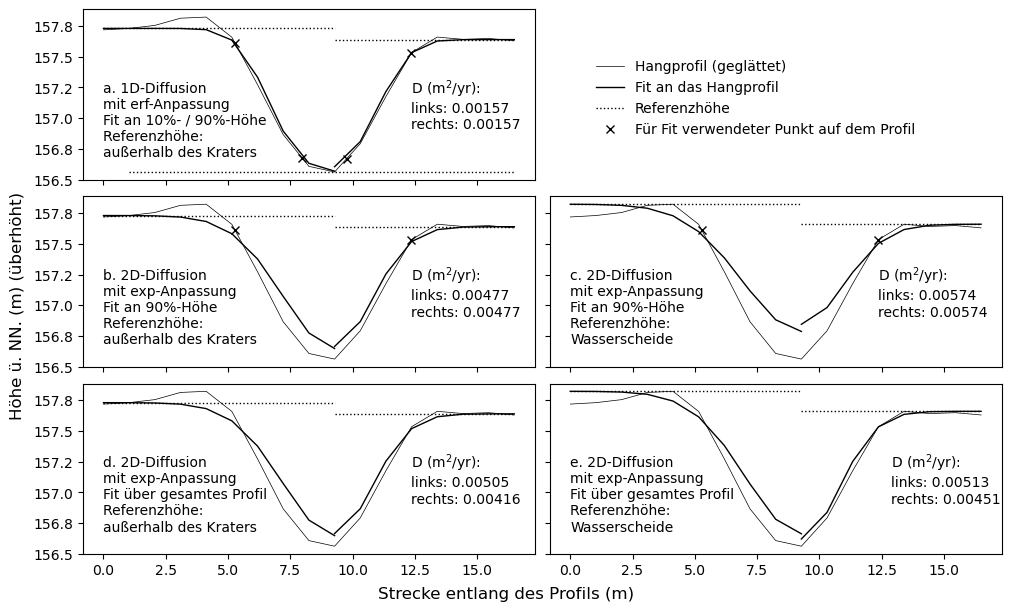

In [25]:
## 3x2 Plot with allen 5 profile-fits
mpl.rcParams.update({
  "font.size": 5, "axes.labelsize": 6, "axes.titlesize": 6,
  "xtick.labelsize": 10, "ytick.labelsize": 10,
  "legend.fontsize": 5, "lines.linewidth": 0.5, "lines.markersize": 3
})

fig, axs = plt.subplots(3,2, figsize=(10,6), sharex=True, sharey=True, constrained_layout=True)
# plotten ...
for ax in axs.ravel():
    ax.plot(s, z_for_analysis, color='black', linewidth=0.5) 

# (top left): 1D-model 
axs[0,0].plot(s_left, z_r1D_left, linewidth=1, color='black') # , label='Fehlerfunktionsanpassung'
axs[0,0].plot(s_right, z_r1D_right, linewidth=1, color='black')
axs[0,0].text(res_right['s90_right'], res_right['z10_right']+deltaz_right*0.4, f"D (m$^2$/yr): \nlinks: {D_r_left:.5f}\nrechts: {D_r_right:.5f}", va='center', ha='left', fontsize=10)
axs[0,0].text(0, z_bot+0.1,f"a. 1D-Diffusion \nmit erf-Anpassung\nFit an 10%- / 90%-Höhe\nReferenzhöhe: \naußerhalb des Kraters",va='bottom', ha='left', fontsize=10)
axs[0,0].plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=6, markeredgewidth=1)
axs[0,0].plot(res_right['s90_right'], res_right['z90_right'], marker='x', color='k', markersize=6, markeredgewidth=1)
axs[0,0].plot([s[0], s_bot], [zr_left, zr_left], color='k', linewidth=1, linestyle=':')
axs[0,0].plot([s_bot, s[-1]], [zr_right, zr_right], color='k', linewidth=1, linestyle=':')
axs[0,0].plot([s[1],s[-1]], [z_bot, z_bot], linestyle=':',color='black', linewidth=1)
axs[0,0].plot(res_left['s10_left'], res_left['z10_left'], marker='x', color='k', markersize=6, markeredgewidth=1)
axs[0,0].plot(res_right['s10_right'], res_right['z10_right'], marker='x', color='k', markersize=6, markeredgewidth=1)

# (mid left): 2D-model fit with 90%-radius and reference level outside of crater 
axs[1,0].plot(s_right, z_ref_2D_fit_right, linewidth=1, color='black') #, label='Anpassung nach radialer Diffusion'
axs[1,0].plot(s_left, z_ref_2D_fit_left, linewidth=1, color='black')
axs[1,0].text(res_right['s90_right'], res_right['z10_right']+deltaz_right*0.4, f"D (m$^2$/yr): \nlinks: {D_r2D_ref_left:.5f}\nrechts: {D_r2D_ref_right:.5f}", va='center', ha='left', fontsize=10)
axs[1,0].text(0, z_bot+0.1,f"b. 2D-Diffusion \nmit exp-Anpassung\nFit an 90%-Höhe\nReferenzhöhe: \naußerhalb des Kraters",va='bottom', ha='left', fontsize=10)
axs[1,0].plot([s[0], s_bot], [zr_left, zr_left], color='k', linewidth=1, linestyle=':')
axs[1,0].plot([s_bot, s[-1]], [zr_right, zr_right], color='k', linewidth=1, linestyle=':')
axs[1,0].plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=6, markeredgewidth=1)
axs[1,0].plot(res_right['s90_right'], res_right['z90_right'], marker='x', color='k', markersize=6, markeredgewidth=1)

# (mid right): 2D-model fit with 90%-radius and drainage devide as reference level 
axs[1,1].plot(s_right, z_2D_fit_right, linewidth=1, color='black') #, label='Anpassung nach radialer Diffusion'
axs[1,1].plot(s_left, z_2D_fit_left, linewidth=1,color='black')
axs[1,1].text(res_right['s90_right'], res_right['z10_right']+deltaz_right*0.4, f"D (m$^2$/yr): \nlinks: {D_r2D_left:.5f}\nrechts: {D_r2D_right:.5f}", va='center', ha='left', fontsize=10)
axs[1,1].text(0, z_bot+0.1,f"c. 2D-Diffusion \nmit exp-Anpassung\nFit an 90%-Höhe\nReferenzhöhe: \nWasserscheide",va='bottom', ha='left', fontsize=10)
axs[1,1].plot([s[0], s_bot], [z_devide_left, z_devide_left], color='k', linewidth=1, linestyle=':')
axs[1,1].plot([s_bot, s[-1]], [z_devide_right, z_devide_right], color='k', linewidth=1, linestyle=':')
axs[1,1].plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=6, markeredgewidth=1)
axs[1,1].plot(res_right['s90_right'], res_right['z90_right'], marker='x', color='k', markersize=6, markeredgewidth=1)

# (bottom left): 2D-model, least squares fit and reference level outside of the crater
axs[2,0].plot(s_right, z_ref_2D_fit_right, linewidth=1, color='black')  #, label='Anpassung nach radialer Diffusion'
axs[2,0].plot(s_left, z_ref_2D_fit_left, linewidth=1, color='black')
axs[2,0].text(res_right['s90_right'], res_right['z10_right']+deltaz_right*0.4, f"D (m$^2$/yr): \nlinks: {D_2Dfit_left:.5f}\nrechts: {D_2Dfit_right:.5f}", va='center', ha='left', fontsize=10)
axs[2,0].text(0, z_bot+0.1,f"d. 2D-Diffusion \nmit exp-Anpassung\nFit über gesamtes Profil\nReferenzhöhe: \naußerhalb des Kraters",va='bottom', ha='left', fontsize=10)
axs[2,0].plot([s[0], s_bot], [zr_left, zr_left], color='k', linewidth=1, linestyle=':')
axs[2,0].plot([s_bot, s[-1]], [zr_right, zr_right], color='k', linewidth=1.0, linestyle=':')

# (bottom right): 2D-model,  least squares fit and drainage devide as reference level 
axs[2,1].plot(s_right, z_devide_2D_fit_right, linewidth=1,color='black') #, label='Anpassung nach radialer Diffusion'
axs[2,1].plot(s_left, z_devide_2D_fit_left, linewidth=1,color='black')
axs[2,1].text(res_right['s90_right']+0.5, res_right['z10_right']+deltaz_right*0.4, f"D (m$^2$/yr): \nlinks: {D_2Dfit_devide_left:.5f}\nrechts: {D_2Dfit_devide_right:.5f}", va='center', ha='left', fontsize=10)
axs[2,1].text(0, z_bot+0.1,f"e. 2D-Diffusion \nmit exp-Anpassung\nFit über gesamtes Profil\nReferenzhöhe: \nWasserscheide",va='bottom', ha='left', fontsize=10)
axs[2,1].plot([s[0], s_bot], [z_devide_left, z_devide_left], color='k', linewidth=1, linestyle=':')
axs[2,1].plot([s_bot, s[-1]], [z_devide_right, z_devide_right], color='k', linewidth=1, linestyle=':')


# central Labels:
fig.supxlabel('Strecke entlang des Profils (m)', fontsize=12) 
fig.supylabel('Höhe ü. NN. (m) (überhöht)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Legend
h1 = Line2D([0], [0], color='black', linewidth=0.5, label='Hangprofil (geglättet)')
h2 = Line2D([0], [0], color='black', linewidth=1.0, label='Anpassung nach radialer Diffusion')
h3 = Line2D([0], [0], color='black', linewidth=1.0, linestyle=':', label='Referenzhöhe')
h4 = Line2D([0], [0], color='black', linewidth=1.0, marker='x', markersize=6, markeredgewidth=1, linestyle='None', label='90%-Höhe')
bbox = axs[0,1].get_position()
fig.legend(handles=[h1, h2, h3, h4], labels=['Hangprofil (geglättet)', 'Fit an das Hangprofil','Referenzhöhe', 'Für Fit verwendeter Punkt auf dem Profil'], 
           loc='upper left',
           bbox_to_anchor=(bbox.x0 + 0.03, bbox.y1 + 0.05),  # etwas inset innerhalb bbox
           bbox_transform=fig.transFigure,
           fontsize=10,
           frameon=False)
           #loc='upper center',
           #bbox_to_anchor=(0.5, -0.01),  # x=0.5 mittig, y negative verschiebt nach unten
           #ncol=4, fontsize=10, frameon=False)
axs[0, 1].set_visible(False)
plt.savefig("2x2_alle5_fits.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 7c) Hangprofil unter zunehmender Diffusion nach 1D- und 2D-Modell (Abb. 4)

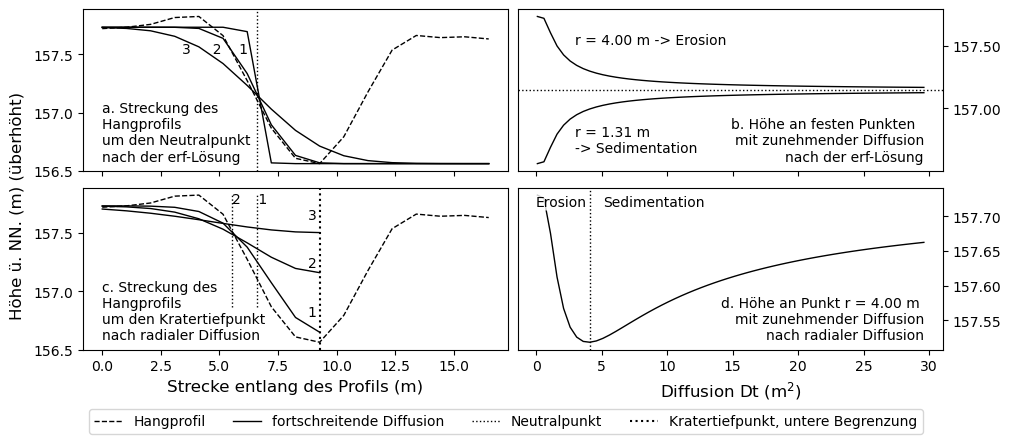

2.6585416134967215


In [26]:

# parameters for 1D-diffusion plots
sigma_left0 = np.sqrt(0.1*D_left * t)
z_model_left0 = erf_step_left(s, z_bot, res_left['z_top_left'], s0_left, sigma_left0)
sigma_left3 = np.sqrt(10*D_left * t)
z_model_left3 = erf_step_left(s, z_bot, res_left['z_top_left'], s0_left, sigma_left3)

# figure
fig, axes = plt.subplots(2,2, figsize=(10,4), sharex=False, sharey=False, constrained_layout=True)
ax00 = axes[0,0]
ax10 = axes[1,0]
ax01 = axes[0,1]
ax11 = axes[1,1]

# (top left): 1D-diffusion hillslope profile
ax00.plot(s, z_for_analysis, linewidth=1, color='black', linestyle='--', label='Hangprofil') # crater profile 
ax00.plot(s, z_model_left, linewidth=1, color='black', label='fortschreitende Diffusion') #erf-fits
ax00.plot(s, z_model_left0, linewidth=1, color='black')
ax00.plot(s, z_model_left3, linewidth=1, color='black')
ax00.axvline((0.5*(res_left['s10_left']-res_left['s90_left']))+res_left['s90_left'], linestyle=':', color='black', linewidth=1)
ax00.text(0,z_bot, f"a. Streckung des \nHangprofils \num den Neutralpunkt \nnach der erf-Lösung", va='bottom', ha='left', fontsize=10) #f"D links: {D_2Dfit_left:.5f}\nD rechts: {D_2Dfit_right:.5f}",
ax00.text(3.4,157.48, '3     2    1', va='bottom', ha='left', fontsize=10) #f"D links: {D_2Dfit_left:.5f}\nD rechts: {D_2Dfit_right:.5f}",

# crater profile (bottom left)
ax10.plot(s, z_for_analysis, linewidth=1, color='black', linestyle='--')
#axs[1,0].plot(s_left, z_ref_2D_fit_left, linewidth=1.5, color='black', label='Fortschreitende Diffusion nach der erf-Lösung')

#plot the profile-fits with radial-diffusion
factor = 2
z_ref_2D_fit_left3 = fit_2D (V_ref_left, s_bot-s_left2, factor*D_r2D_ref_left, z_bot, zr_left, t2_2D_ref_left)
z_ref_2D_fit_left4 = fit_2D (V_ref_left, s_bot-s_left2, 5*D_r2D_ref_left, z_bot, zr_left, t2_2D_ref_left)
ax10.plot(s_left, z_ref_2D_fit_left3, linewidth=1, color='black') #, label='Fortschreitende radiale Diffusion'
ax10.plot(s_left, z_ref_2D_fit_left, linewidth=1, color='black')
ax10.plot(s_left, z_ref_2D_fit_left4, linewidth=1, color='black')
#ax10.plot(s, z_model_left, linewidth=1, color='black', label='Fortschreitende Diffusion nach der erf-Lösung')
#ax10.plot(s, z_model_left3, linewidth=1, color='black')



# bottom left: neutral spots (erosion/sedimentation)
s_rim = (0.5*(res_left['s10_left']-res_left['s90_left']))+res_left['s90_left']
z_50 = (z_ref_2D_fit_left[np.floor(s_rim).astype(int)])-((z_ref_2D_fit_left[np.floor(s_rim).astype(int)])-(z_ref_2D_fit_left[np.ceil(s_rim).astype(int)]))*(s_rim-np.floor(s_rim).astype(int)) #-0.1 #
ax10.plot([s_rim, s_rim], [z_bot+0.3, z_devide_left], linestyle=':', color='black', linewidth=1,label='Neutralpunkt')
#ax[0,1].axvline((0.5*(res_left['s10_left']-res_left['s90_left']))+res_left['s90_left'], linestyle=':', color='black')

s_rim3 = s_bot-np.sqrt(factor)*(s_bot-s_rim)
z_50_3 = (z_ref_2D_fit_left3[np.floor(s_rim3).astype(int)])-((z_ref_2D_fit_left3[np.floor(s_rim3).astype(int)])-(z_ref_2D_fit_left3[np.ceil(s_rim3).astype(int)]))*(s_rim3-np.floor(s_rim3).astype(int))#z_ref_2D_fit_left3[np.rint(s_rim3).astype(int)]
ax10.plot([s_rim3, s_rim3], [z_bot+0.3, z_devide_left], color='k', linewidth=1, linestyle=':')

# bottom left: labels and crater bottom
ax10.text(0,z_bot, f"c. Streckung des \nHangprofils \num den Kratertiefpunkt\nnach radialer Diffusion", va='bottom', ha='left', fontsize=10)
ax10.axvline(s_bot, color='k', linewidth=1.5, linestyle=':', label='Kratertiefpunkt, untere Begrenzung')
ax10.text(s_bot-0.5,z_bot+0.2, f"3 \n\n \n2\n\n\n1", va='bottom', ha='left', fontsize=10)
ax10.text(s_rim3,zr_left, '2    1', va='bottom', ha='left', fontsize=10)

# top right: Z(DT) 1D-plots for fixed Radius
tao = np.arange(0.1, 30.1, 0.5) #tao=Dt
Z_von_Dt_1D_90 = erf_step_left(res_left['s90_left'], z_bot, res_left['z_top_left'], s0_left, tao) 
Z_von_Dt_1D_10 = erf_step_left(res_left['s10_left'], z_bot, res_left['z_top_left'], s0_left, tao) 
ax01.plot(tao, Z_von_Dt_1D_90, color='k', linewidth=1)
ax01.plot(tao, Z_von_Dt_1D_10, color='k', linewidth=1)
ax01.text(0.1*tao[-1],Z_von_Dt_1D_90[2], f"r = {s_bot-res_left['s90_left']:.2f} m -> Erosion",color='black', va='top', ha='left', fontsize=10)
ax01.text(0.1*tao[-1],Z_von_Dt_1D_10[4], f"r = {s_bot-res_left['s10_left']:.2f} m \n-> Sedimentation",color='black', va='top', ha='left', fontsize=10)
ax01.text(tao[-1],min(Z_von_Dt_1D_10), f"b. Höhe an festen Punkten  \nmit zunehmender Diffusion\nnach der erf-Lösung", va='bottom', ha='right', fontsize=10)
ax01.axhline(z_bot+0.5*(zr_left-z_bot), linestyle=':', color='k', linewidth=1)


# Z(Dt) 2D-plot for fixed Radius
def Z_von_Dt_2D(tao): 
    return zr_left - (V_ref_left/(4*np.pi*tao)*np.exp(-(s_bot-res_left['s90_left'])**2/(4*tao))) #     
ax11.plot(tao, Z_von_Dt_2D(tao), color='k', linewidth=1)
ax11.text(tao[-1],min(Z_von_Dt_2D(tao)), f"d. Höhe an Punkt r = {(s_bot-res_left['s90_left']):.2f} m \nmit zunehmender Diffusion\nnach radialer Diffusion", va='bottom', ha='right', fontsize=10)

# bottom right: placing the labels and neutral spot
def tao_bot():
    Z = Z_von_Dt_2D(tao)
    idx = np.argsort(Z)
    Zs = Z[idx]
    taos = tao[idx]

    f_inv = interp1d(Zs, taos, kind='linear', bounds_error=False, fill_value=np.nan)
    
    Z_target = Z.min()   
    tao_bot = f_inv(Z_target)
    return float(tao_bot)
tao_bot = tao_bot()

ax11.axvline(tao_bot, color='black',linewidth=1,linestyle=':')
ax11.text(0,Z_von_Dt_2D(0.1), 'Erosion',color='black', va='top', ha='left', fontsize=10, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.1'))
ax11.text(tao_bot+1,Z_von_Dt_2D(0.1), 'Sedimentation',color='black', va='top', ha='left', fontsize=10)


# Achsis positions and labels
for ax in (ax00, ax10):
    ax.yaxis.set_label_position("left"); ax.yaxis.tick_left()
for ax in (ax01, ax11):
    ax.yaxis.set_label_position("right"); ax.yaxis.tick_right(); ax.yaxis.set_ticks_position("right")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_ticks_position("right")

for ax in axs[0, :]:
    ax.set_xlabel('')
ax10.set_xlabel('Strecke entlang des Profils (m)', fontsize=12)    # linke Spalte
ax11.set_xlabel(f"Diffusion Dt (m$^2$)", fontsize=12)  

# remove upper x-label 
for ax in (axes[0,0], axes[0,1]):
    ax.set_xticklabels([])
    ax.tick_params(labelbottom=False)

fig.supylabel('Höhe ü. NN. (m) (überhöht)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# legend, plot and save
fig.legend(fontsize=10, frameon=True, loc='lower center', bbox_to_anchor=(0.5, bbox.y1-0.97),
           bbox_transform=fig.transFigure, ncol=4) 
#fig.tight_layout()
plt.savefig("fortschreitende_Diffusion.pdf", dpi=300, bbox_inches="tight")
plt.show()
print(s_bot-s0_left)

## 7d) Visualisierung der Volumenberechnung (Abb. 5)

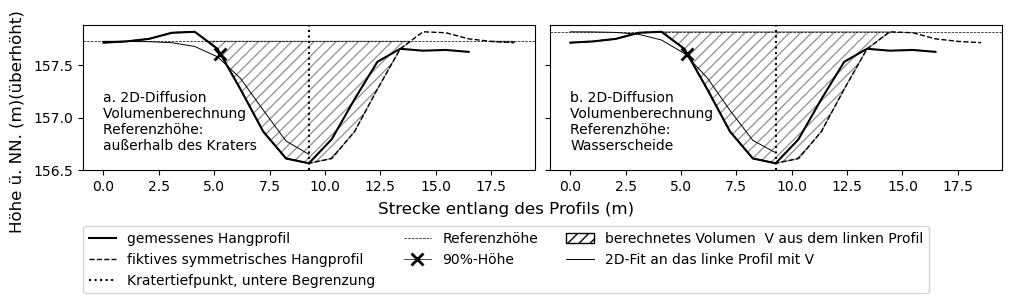

In [27]:
## 2D-fits (z_devide and zr (reference level outside of crateer))

# figure
fig, axes = plt.subplots(1,2, figsize=(10,2), sharex=True, sharey=True, constrained_layout=True)
fig.supxlabel('Strecke entlang des Profils (m)', fontsize=12) 
fig.supylabel('Höhe ü. NN. (m)(überhöht)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# create fictive symmetrical crater profiles
s_symmetrisch = np.concatenate([s_left, s_left2+s_bot])
z_symmetrisch = np.concatenate([z_left_for_analysis, z_left_for_analysis2])
for ax in axes.ravel():
    ax.plot(s, z_for_analysis, color='black', linewidth=1.5, label ='gemessenes Hangprofil') 
    ax.plot(s_symmetrisch, z_symmetrisch, color='black', linestyle='--', linewidth=1, label ='fiktives symmetrisches Hangprofil')
    ax.axvline(s_bot, linestyle = ':', color='black', linewidth = 1.5, label = 'Kratertiefpunkt, untere Begrenzung')

ax0 = axes[0]
ax1 = axes[1]

# left: fit to zr (reference level outside of crater)
ax0.plot(s_left, z_ref_2D_fit_left, linewidth=0.7, color='black')

ax0.axhline(zr_left, linewidth=0.5, color='black', linestyle='--', label = 'Referenzhöhe')
ax0.plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=8, markeredgewidth=2, label='90%-Höhe')

# fill for Volume to zr
mask_ref = (z_symmetrisch < zr_left) #(s < s_bot) &
ax0.fill_between(s_symmetrisch, z_symmetrisch, zr_left, where=mask_ref,
                facecolor='none',alpha=0.4, hatch='///', interpolate=True,
                edgecolor='black')
#label
ax0.text(0, z_bot+0.1,f"a. 2D-Diffusion\nVolumenberechnung \nReferenzhöhe: \naußerhalb des Kraters",va='bottom', ha='left', fontsize=10)

# right: fit to devide
ax1.plot(s_left, z_devide_2D_fit_left, linewidth=0.7, color='black')
# reference level
ax1.axhline(z_devide_left, linewidth=0.5, color='black', linestyle='--')
ax1.plot(res_left['s90_left'], res_left['z90_left'], marker='x', color='k', markersize=8, markeredgewidth=2)

# fill to devide
mask_devide = (z_symmetrisch < z_devide_left) & (s_symmetrisch >= s_devide_left) & (s_symmetrisch <= s_symmetrisch[-1]-s_devide_left)
ax1.fill_between(s_symmetrisch, z_symmetrisch, z_devide_left, where=mask_devide,
                facecolor='none',alpha=0.4, hatch='///', interpolate=True,
                edgecolor='black')
#label
ax1.text(0, z_bot+0.1,f"b. 2D-Diffusion \nVolumenberechnung \nReferenzhöhe: \nWasserscheide",va='bottom', ha='left', fontsize=10)

# legend with handles
handles = []
labels = []
for ax in (ax0, ax1):                       
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            labels.append(ll)
            handles.append(hh)

patch = mpatches.Patch(facecolor='none', edgecolor='black', hatch='///')
dash_handle = mlines.Line2D([], [], color='black', linewidth=0.7)
handles.append(patch); labels.append('berechnetes Volumen  V aus dem linken Profil')
handles.append(dash_handle); labels.append('2D-Fit an das linke Profil mit V')
fig.legend(handles, labels, fontsize=10, frameon=True, loc='upper center', bbox_to_anchor=(0.5, bbox.y1-0.87),
           bbox_transform=fig.transFigure, ncol=3) 

# save and plot
plt.savefig("Kratervolumen.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7) Export
optional: Speichert das gesampelte Profil als CSV.

Ausgabe aller nützlichen Werte zum Kopieren in ein CSV-textdokument

Angegeben sind: Krater Nr. mit a und b für gegenüberliegende Hänge, Vegetation; Breitengrad Längengrad des Tiefpunkts in WGS 84 (EPSG 4326); Azimuth der Hangneigung des Profils; Kraterradius (m) auf dem DGM; Höhenunterschied (m); Wasserscheide erkennbar (True/-); r1(D 1D)(m): Radius der Wasserscheide zum Zeitpunkt des Luftbilds nach dem 1D-Modell; t1(D 1D)(a): Scheinbares Alter des Kraters auf dem Luftbild nach dem 1D-Modell; t2(D 1D)(a) ): Scheinbares Alter des Kraters zum Zeitpunkt des DGM nach dem 1D-Modell; D (1D)(m^2/a: Diffusionskoeffizient nach dem 1D-Modell;   Volume to ref Margin (m3): Kratervolumen bis zum ersten Schnittpunkt mit der Referenzhöhe außerhalb des Kraters; r1 (ref 2D)(m): Radius der Wasserscheide zum Zeitpunkt des Luftbilds nach dem 2D-Modell mit Anpassung an die Referenzhöhe außerhalb des Kraters; t1(ref 2D)(a): Scheinbaren Alter des Kraters auf dem Luftbild nach dem 2D-Modell mit Anpassung an die Referenzhöhe außerhalb des Kraters;  t2 (ref 2D)(a): Scheinbaren Alter des Kraters auf dem DGM nach dem 2D-Modell mit Anpassung an die Referenzhöhe außerhalb des Kraters, D 2D 0.9 to ref margin (m^2/a): Diffusionskoeffizient nach dem 2D-Modell mit Anpassung an die 90%-Höhe und die Referenzhöhe außerhalb des Kraters; D 2D from fit to ref margin (m^2/a): Diffusionskoeffizient nach dem 2D-Modell mit Anpassung über das gesamte Profil mit Referenzhöhe außerhalb des Kraters; Volume to devide (m3): Kratervolumen bis zur Wasserscheide; r1 (devide 2D)(m): Radius der Wasserscheide zum Zeitpunkt des Luftbilds nach dem 2D-Modell mit Anpassung an die Wasserscheide; t1(devide 2D)(a): Scheinbares Alter des Kraters zum Zeitpunkt des Luftbilds nach dem 2D-Modell mit Anpassung an die Wasserscheide; t2(devide 2D) (a): Scheinbares Alter des Kraters zum Zeitpunkt des DGM nach dem 2D-Modell mit Anpassung an die Wasserscheide: D 2D 0.9 to devide (m^2/a): Diffusionskoeffizient nach dem 2D-Modell mit Anpassung an die 90%-Höhe mit Wasserscheide als Referenzhöhe, D 2D from fit to devide (m^2/a): Diffusionskoeffizient nach dem 2D-Modell mit Anpassung über das gesamte Profil mit Wasserscheide als Referenzhöhe.

In [28]:
df_prof.to_csv('sampled_profile.csv', index=False)
print('Wrote sampled_profile.csv')

Wrote sampled_profile.csv


In [29]:
if z_devide_right-zr_right < 0.03*deltaz_right:
    Devide_right = False
else: Devide_right = True
if z_devide_left-zr_left < 0.03*deltaz_left:
    Devide_left = False
else: Devide_left = True
#print all useful results in CSV format (PROFILE_SHP name should contain: Craternumber(+a/b/c),",", vegetation)
print ('9a,Wald, ',f"{lat:.8f}, {lon:.8f}",', ',Azimut_left,', ',r_left,', ',deltaz_left,', ',Devide_left,', ',r1_left,', ',t1_left,', ',t2_left,', ',D_r_left,', ',V_ref_left,', ',r1_2D_ref_left,', ',t1_2D_ref_left,', ',t2_2D_ref_left,', ',D_r2D_ref_left,', ',D_2Dfit_left,', ',V_devide_left,', ',r1_2D_left,', ',t1_2D_left,', ',t2_2D_left,', ',D_r2D_left,', ',D_2Dfit_devide_left)
print ('9a,Wald,',f"{lat:.8f}, {lon:.8f}",', ',Azimut_right,', ',r_right,', ',deltaz_right,', ',Devide_right,', ',r1_right,', ',t1_right,', ',t2_right,', ',D_r_right,', ',V_ref_right,', ',r1_2D_ref_right,', ',t1_2D_ref_right,', ',t2_2D_ref_right,', ',D_r2D_ref_right,', ',D_2Dfit_right,', ',V_devide_right,', ',r1_2D_right,', ',t1_2D_right,', ',t2_2D_right,', ',D_r2D_right,', ',D_2Dfit_devide_right)
       

9a,Wald,  50.77965087, 6.90237455 ,  1.1885386092272654 ,  5.153440988209835 ,  1.2605708530970787 ,  True ,  4.543867586865112 ,  272.4386459441408 ,  350.4386459441408 ,  0.0015693321082097993 ,  29.065795119363973 ,  4.65438545266646 ,  345.2213500259415 ,  423.2213500259415 ,  0.004773279382434145 ,  0.005048738639876803 ,  36.03420979022575 ,  4.71814127232526 ,  404.07439486973016 ,  482.07439486973016 ,  0.005743887767171346 ,  0.005129641193330684
9a,Wald, 50.77965087, 6.90237455 ,  181.18853860922727 ,  4.122752790567869 ,  1.097712489536832 ,  False ,  3.5998315559764795 ,  250.2995240239971 ,  328.2995240239971 ,  0.001569332108209799 ,  13.999914289056958 ,  3.4893136901751305 ,  196.9550819688544 ,  274.9550819688544 ,  0.004773279382434137 ,  0.004158059755444131 ,  14.817911795705376 ,  3.42555787051633 ,  173.92148717434546 ,  251.92148717434546 ,  0.005743887767171331 ,  0.004505155273989233
